
# Predictive Persistence Analysis (NBA dataset)


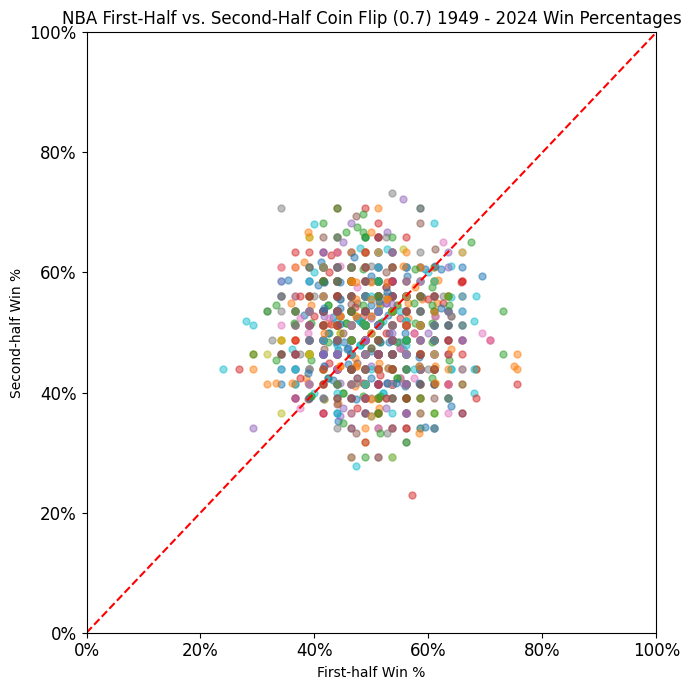

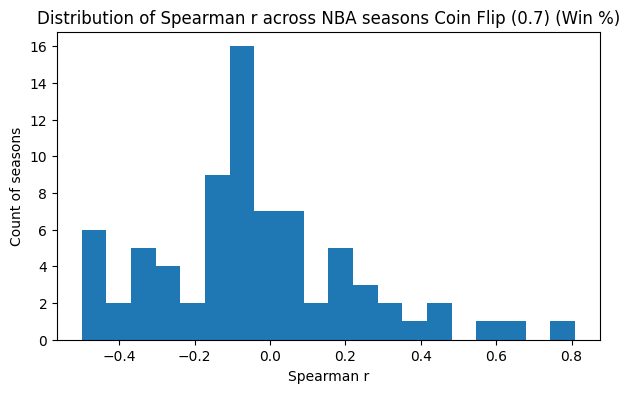


r value meanings:
r closer to 1: first half ranks are very predictive of second half ranks
r closer to 0: first half ranks are NOT very predictive of second half ranks
r negative: reverse tendency. high first half ranks predict low second half ranks, and vice versa


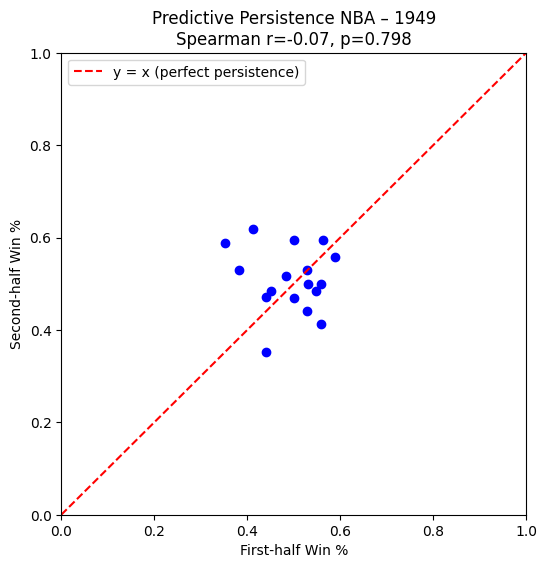

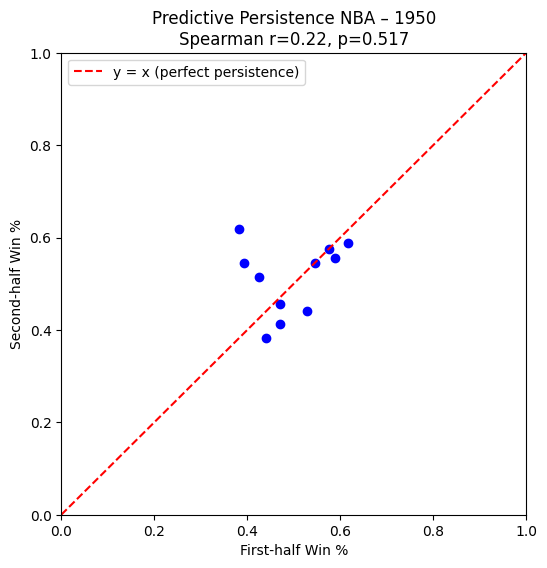

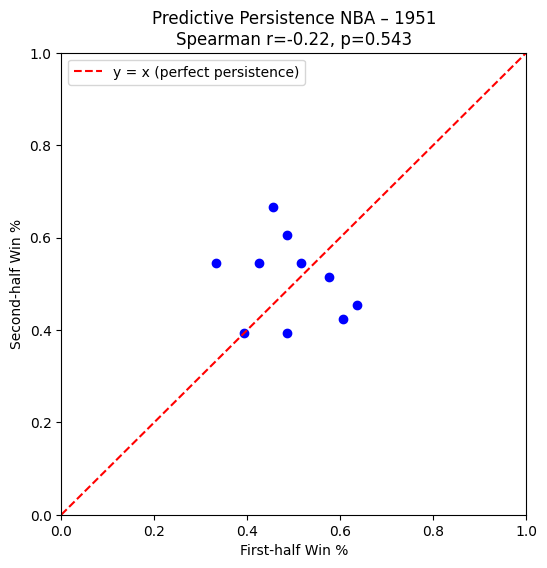

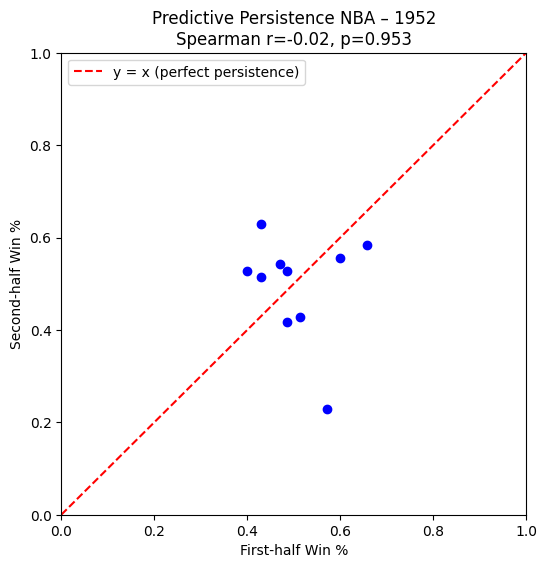

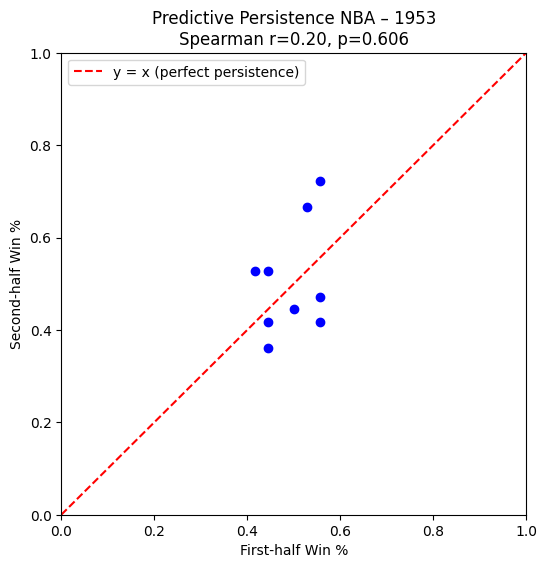

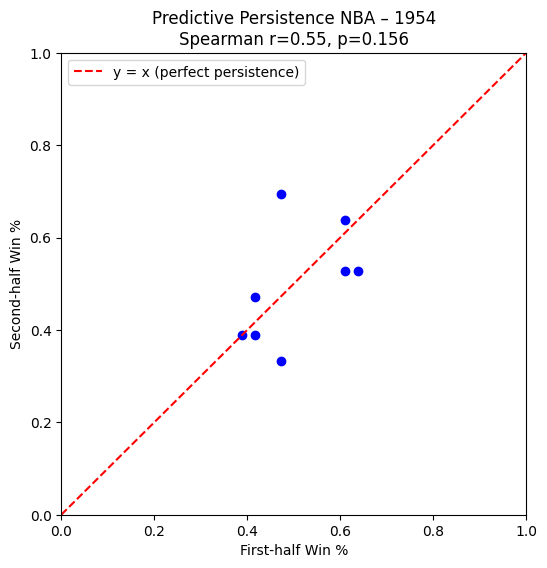

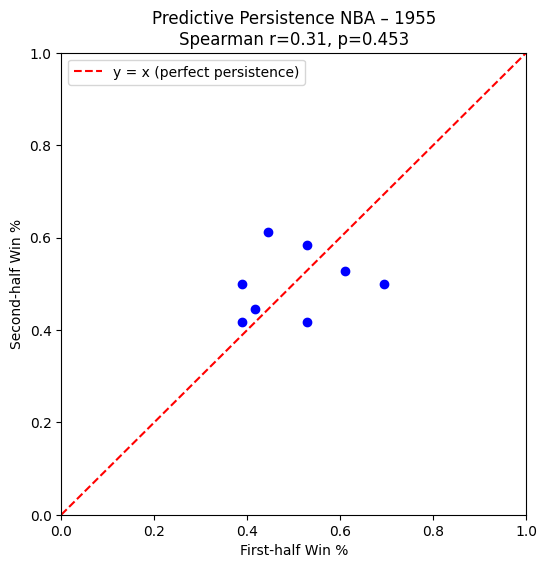

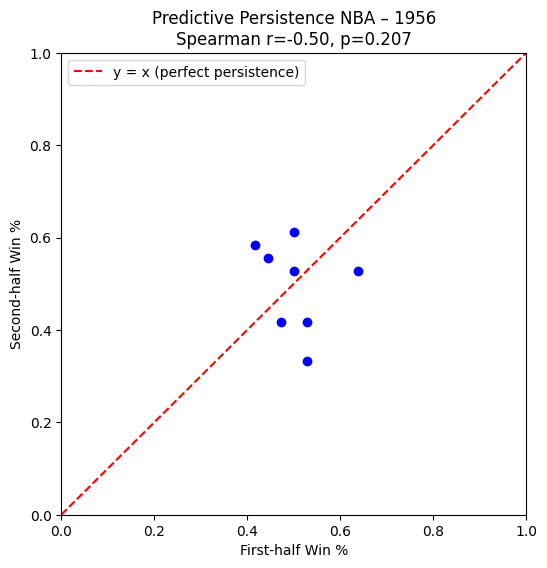

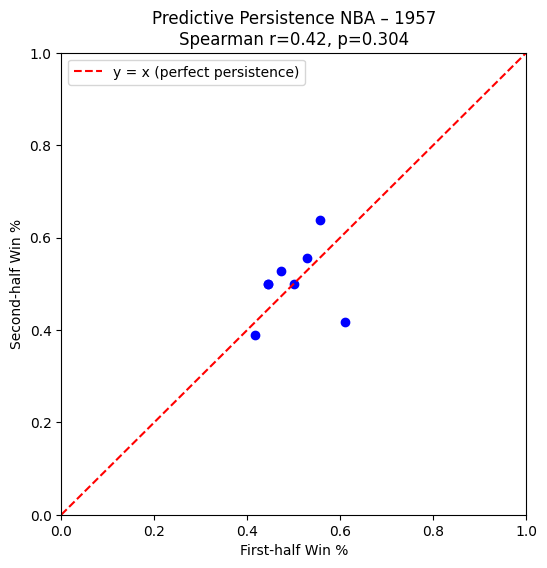

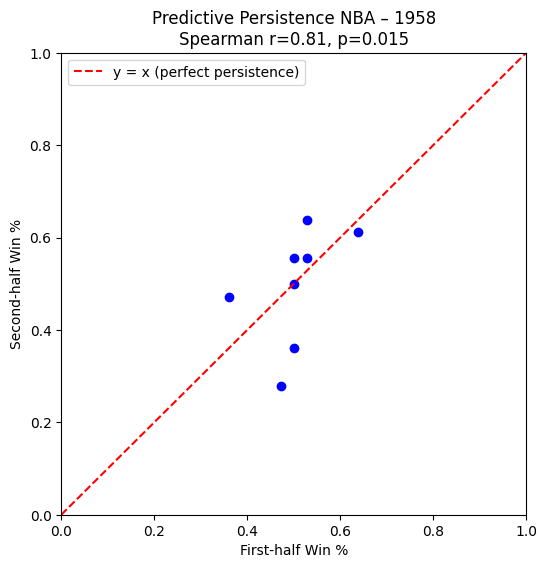

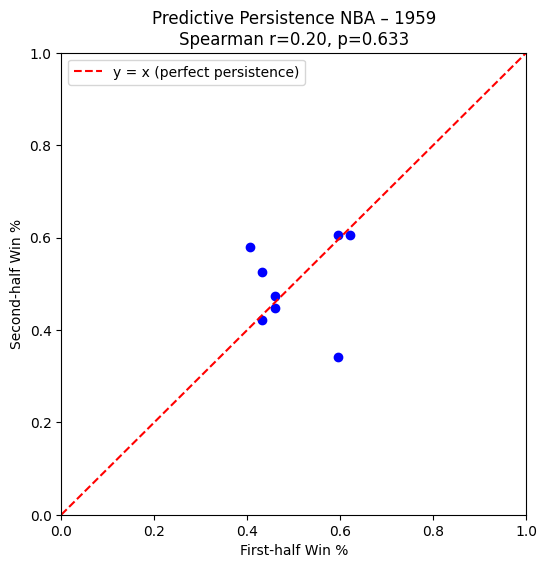

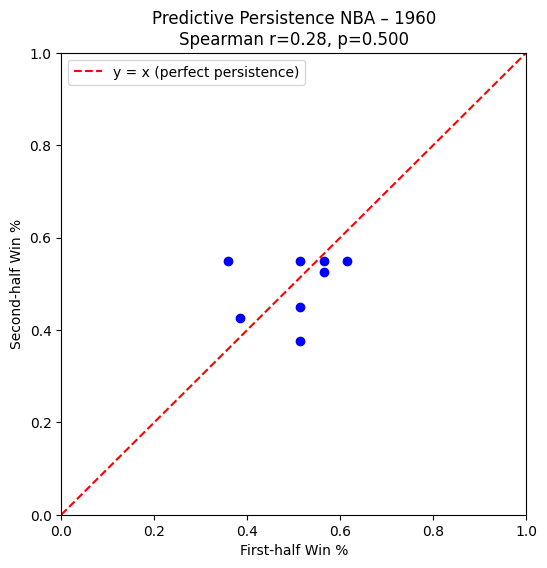

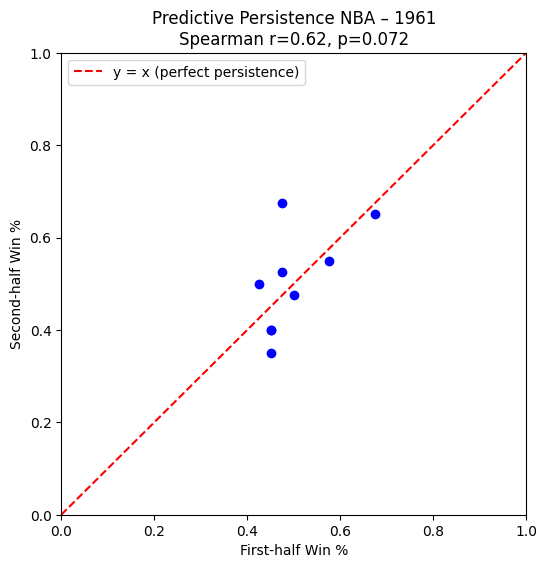

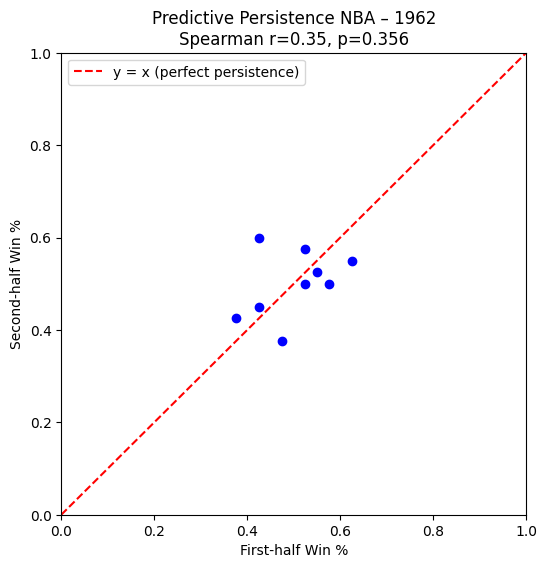

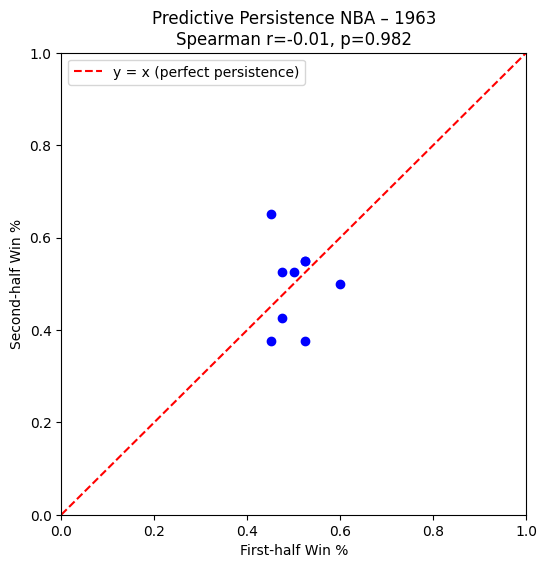

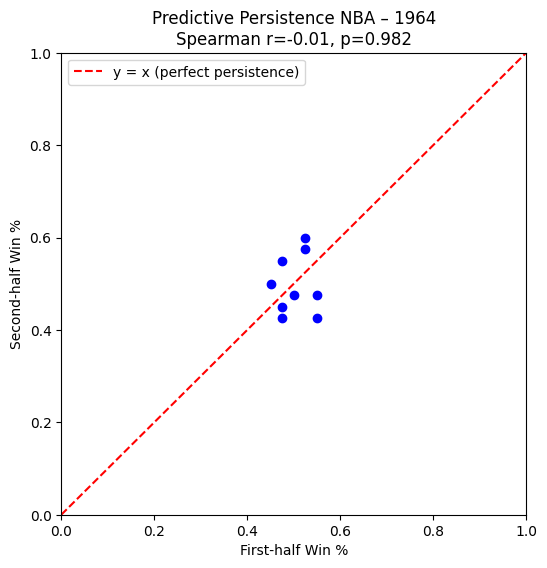

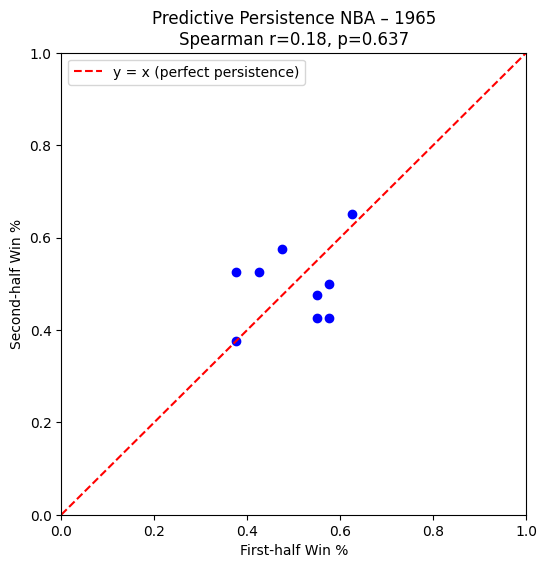

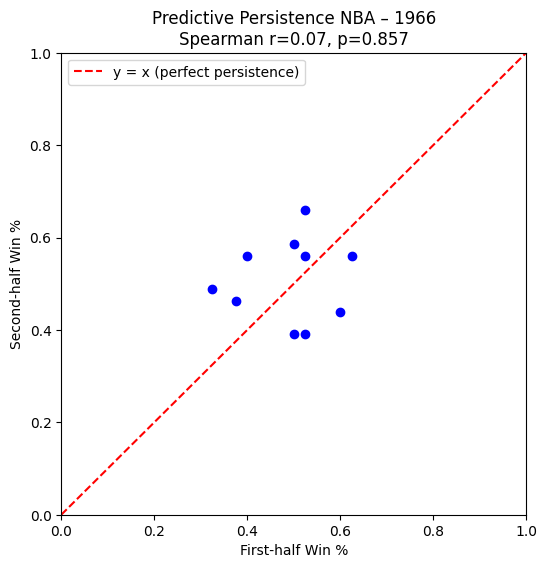

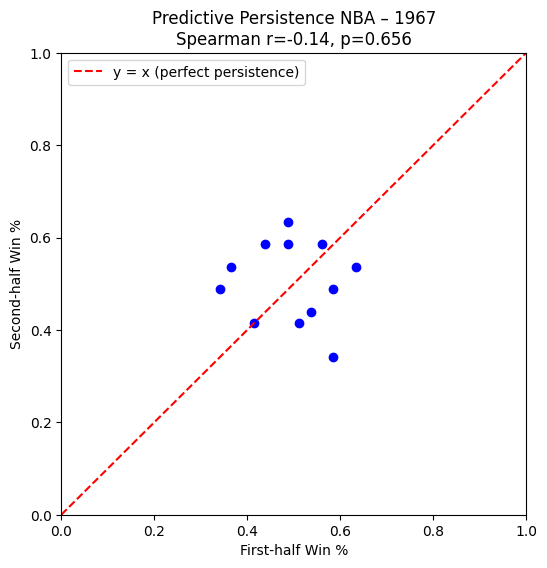

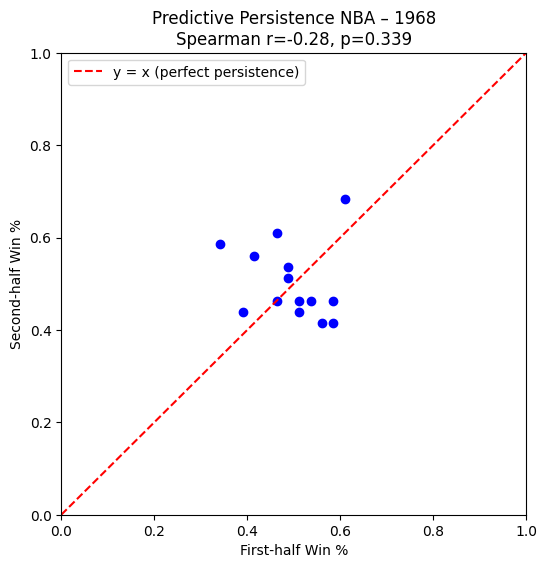

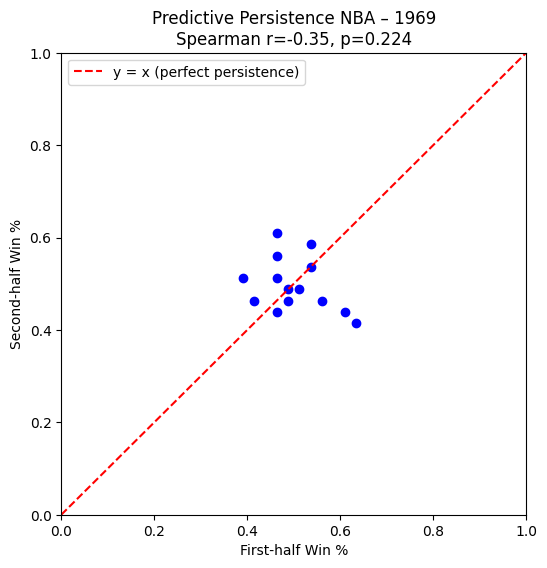

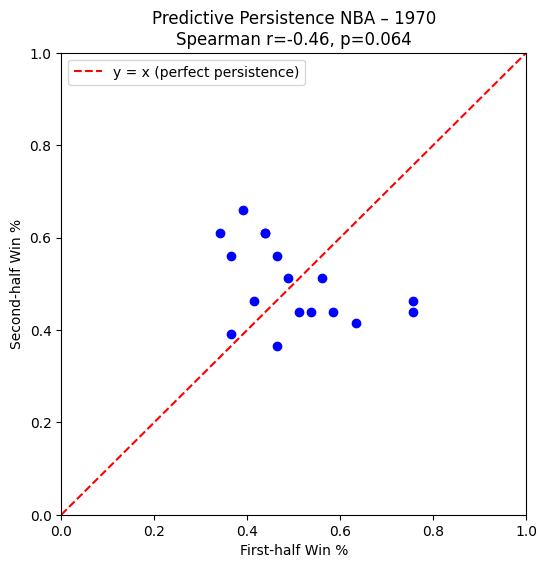

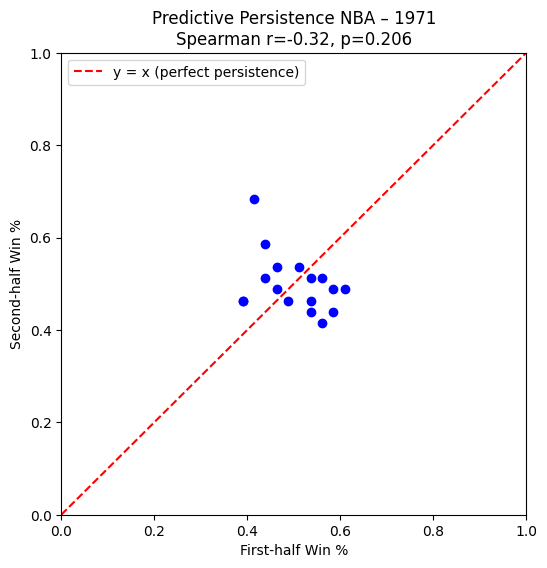

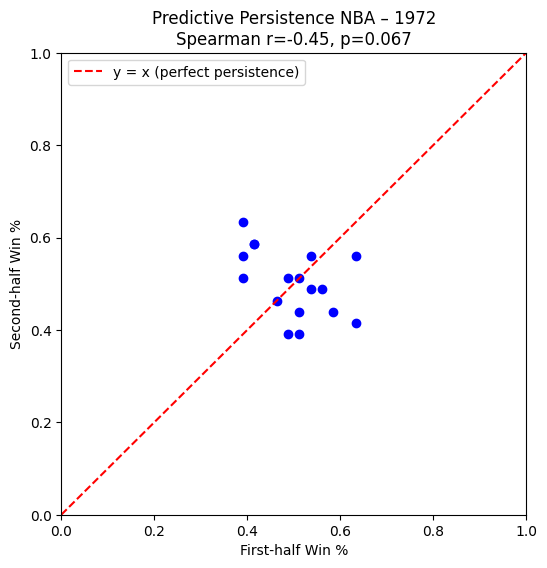

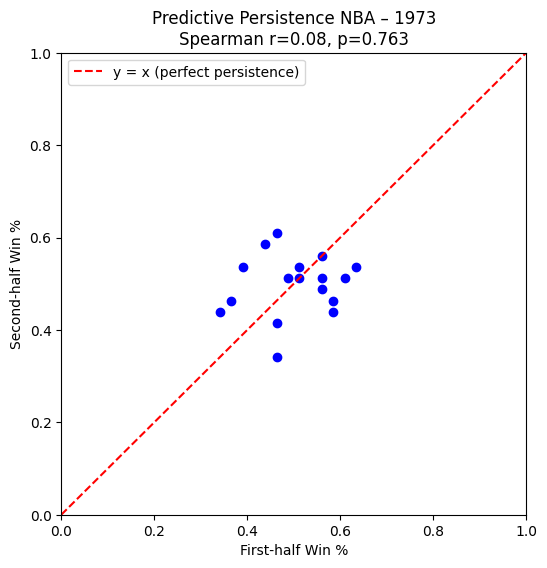

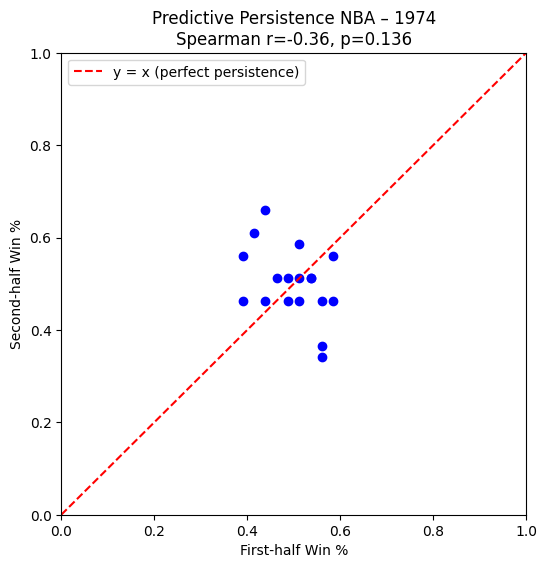

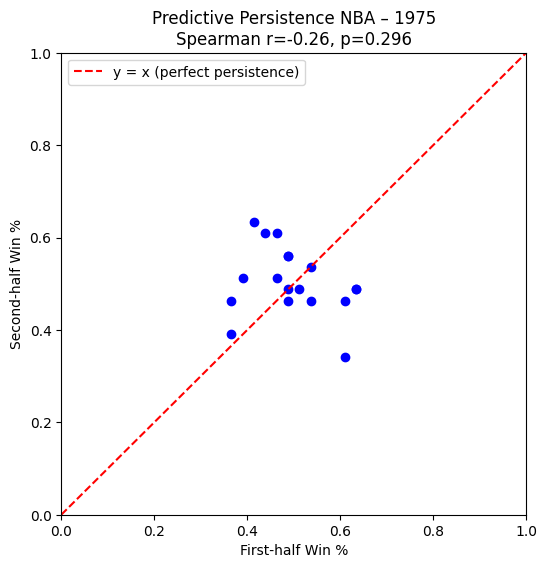

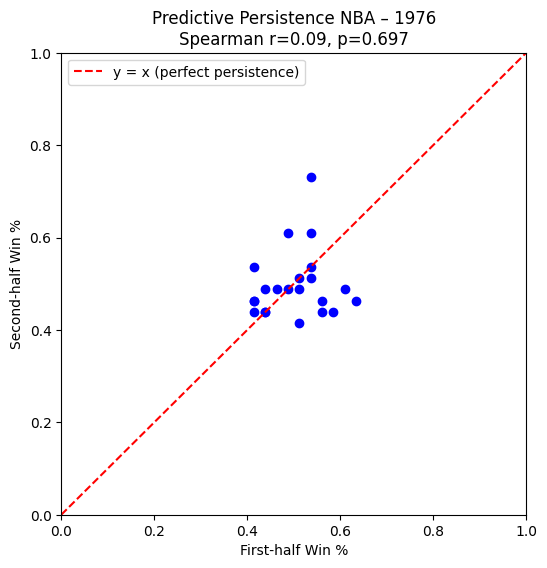

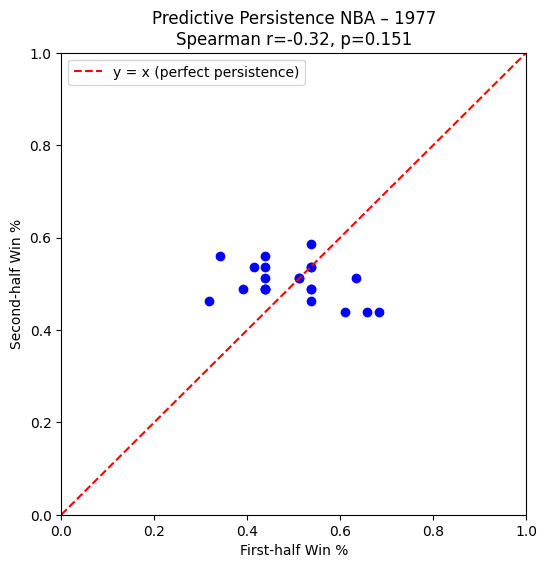

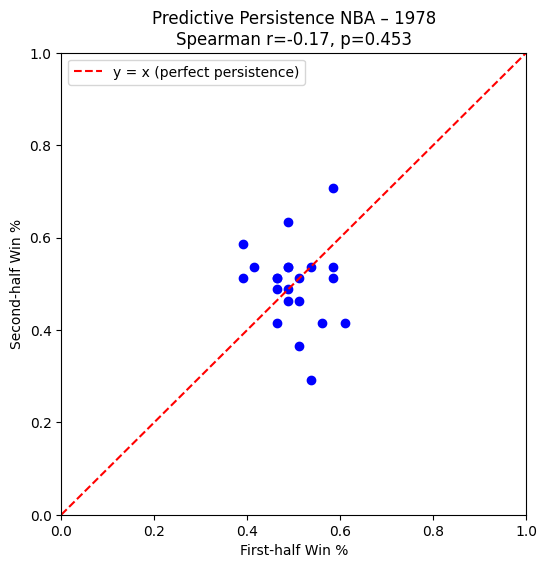

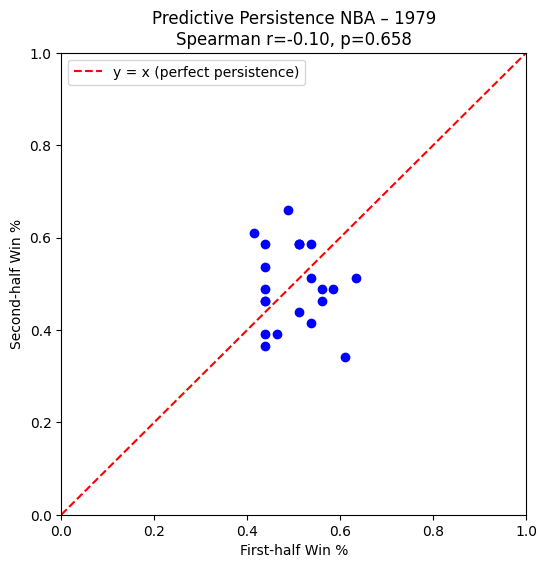

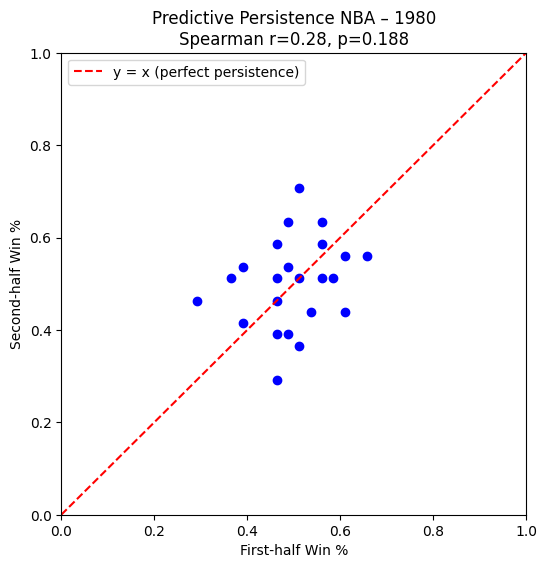

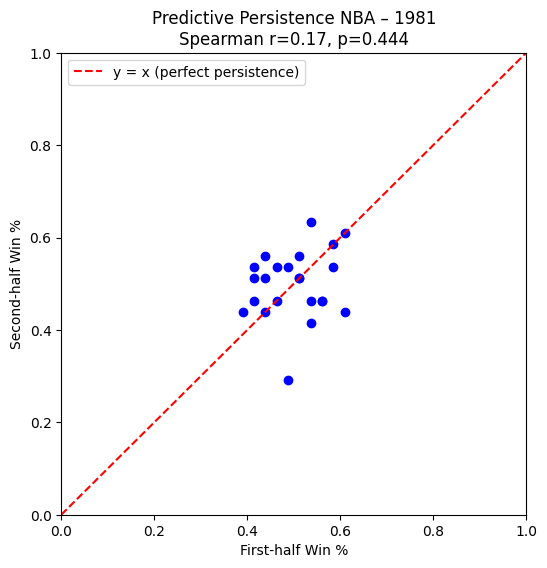

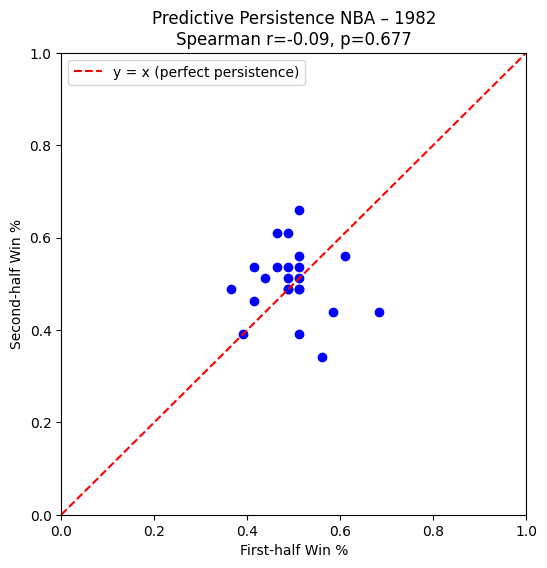

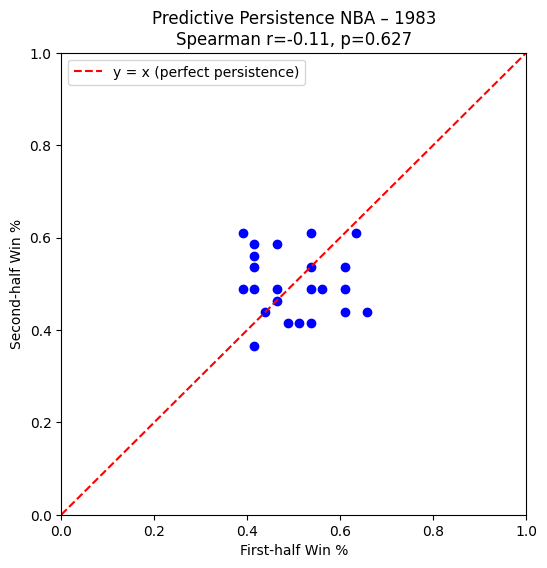

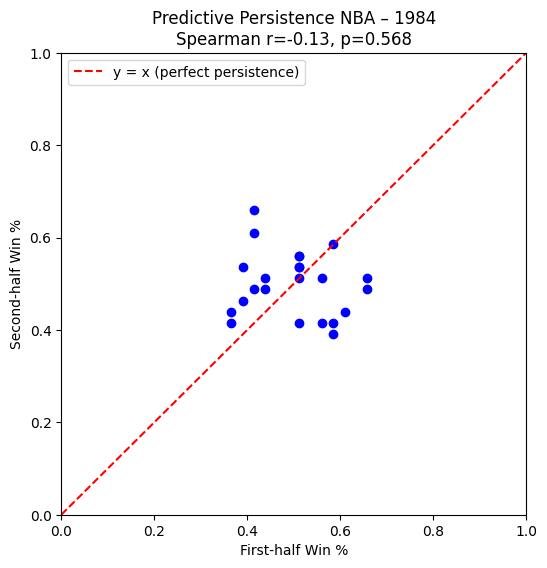

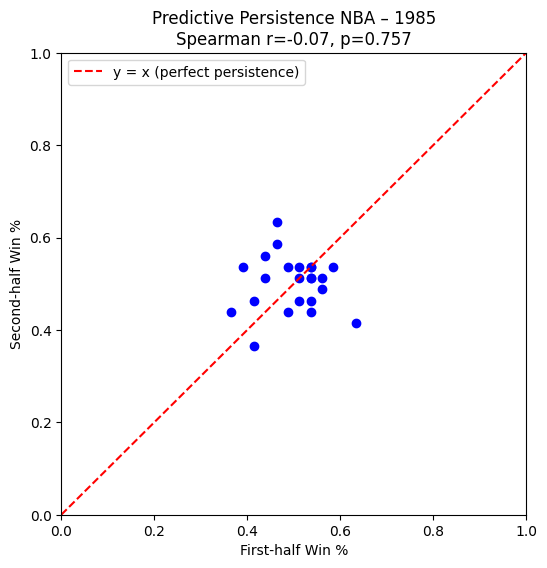

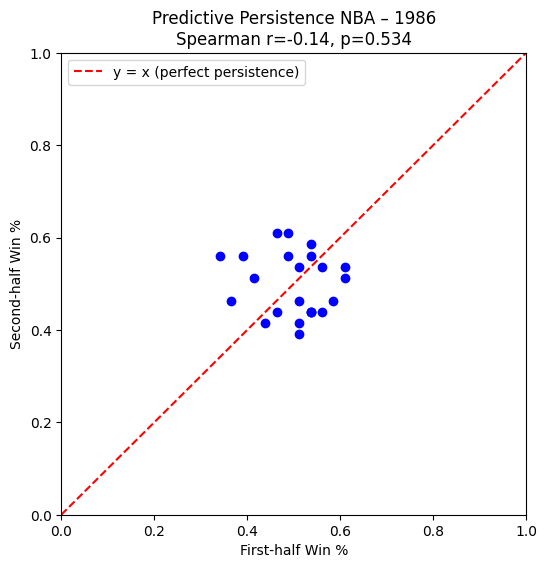

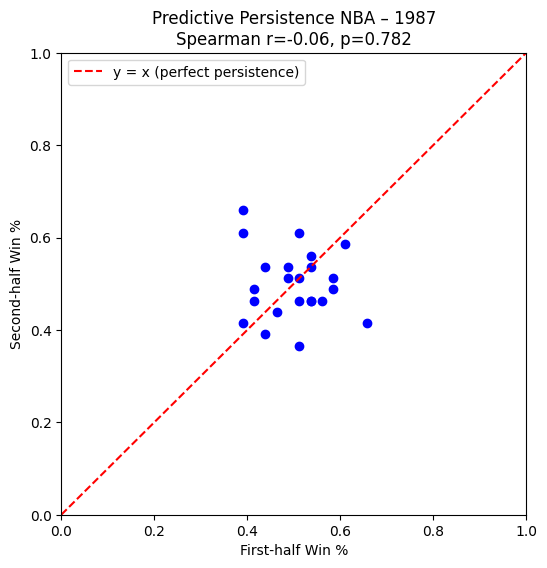

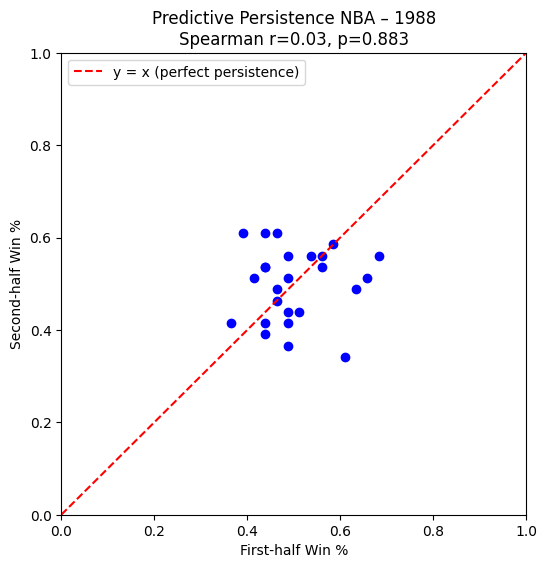

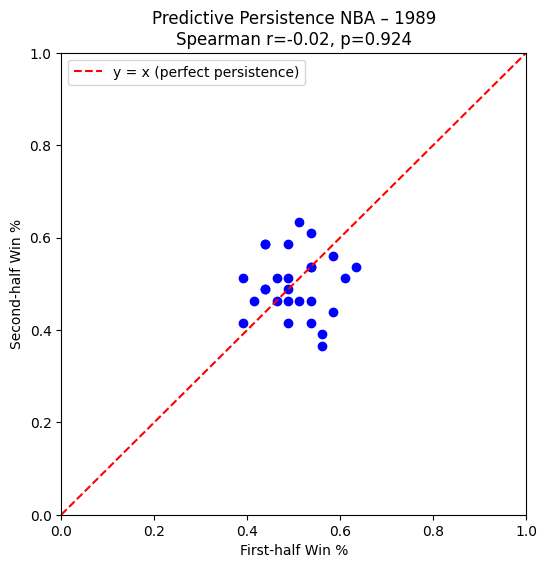

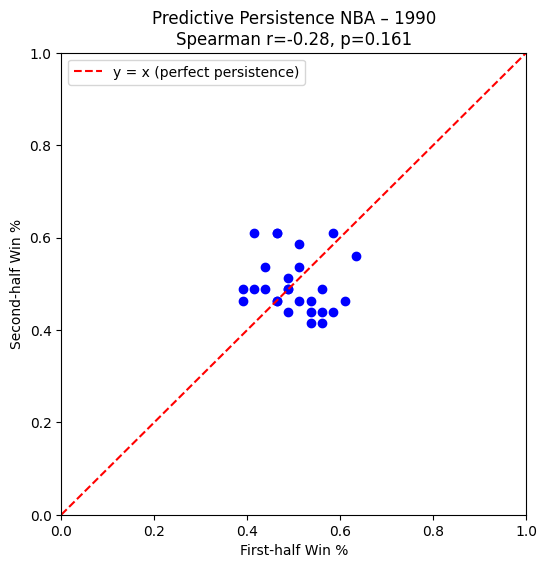

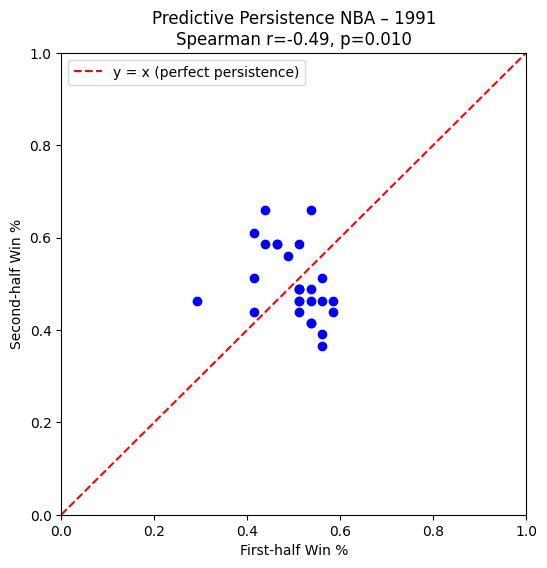

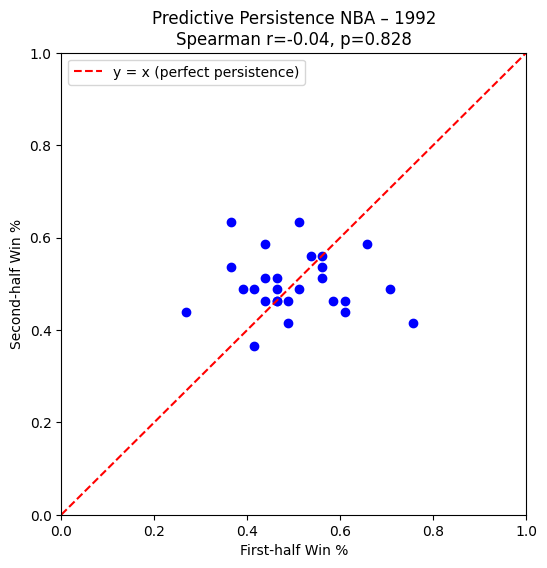

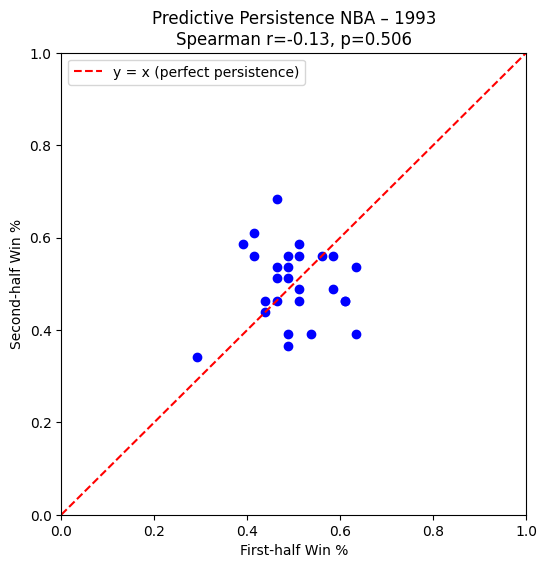

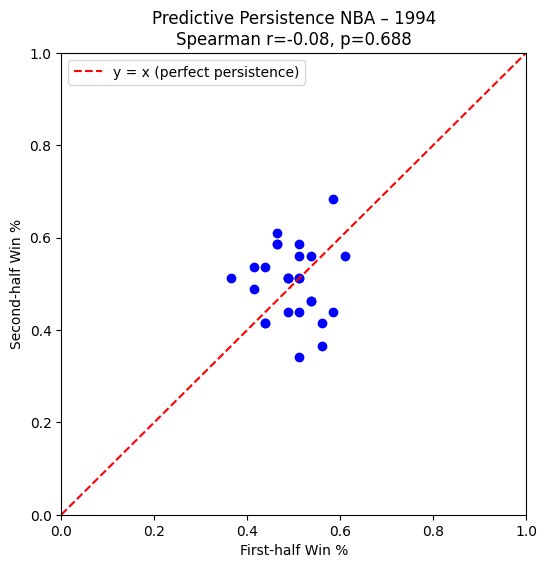

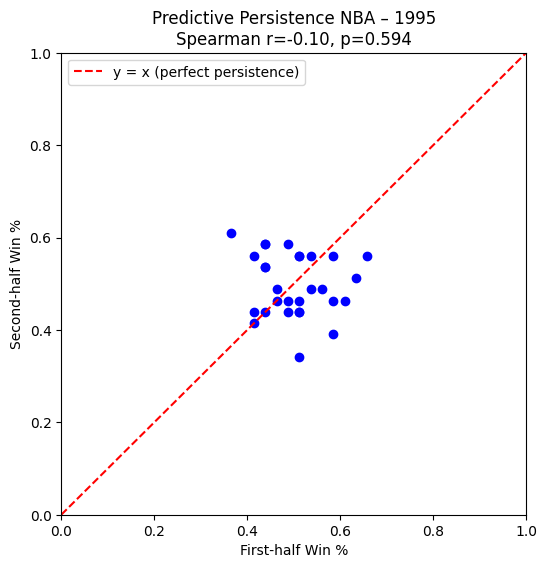

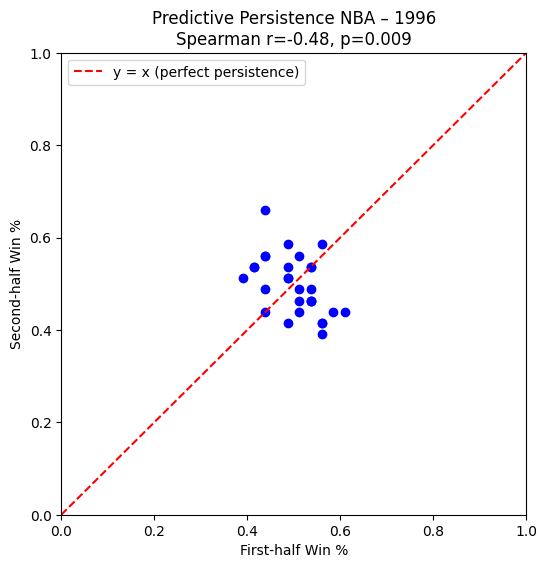

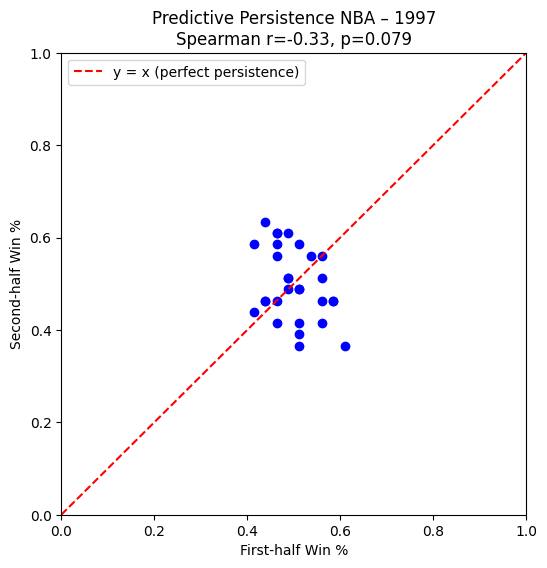

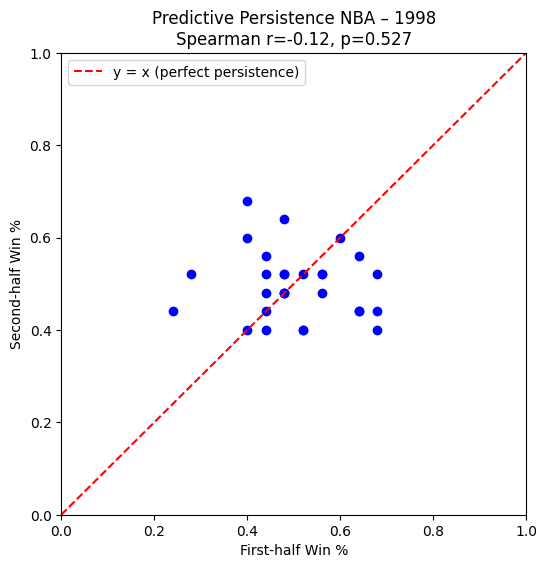

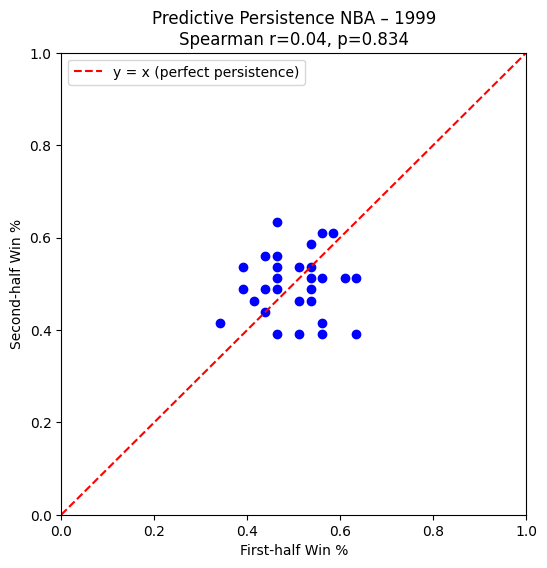

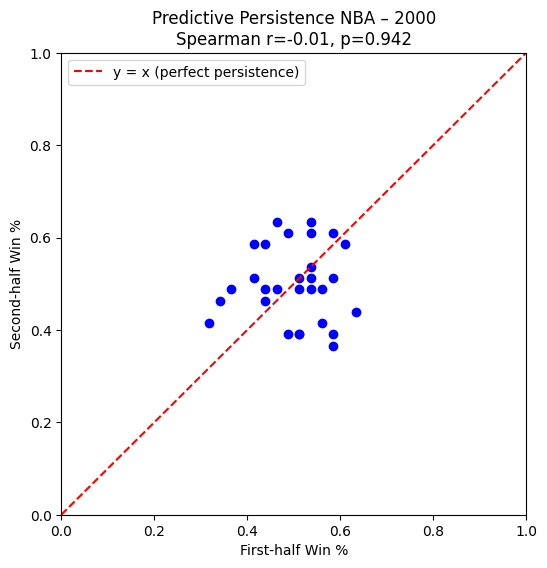

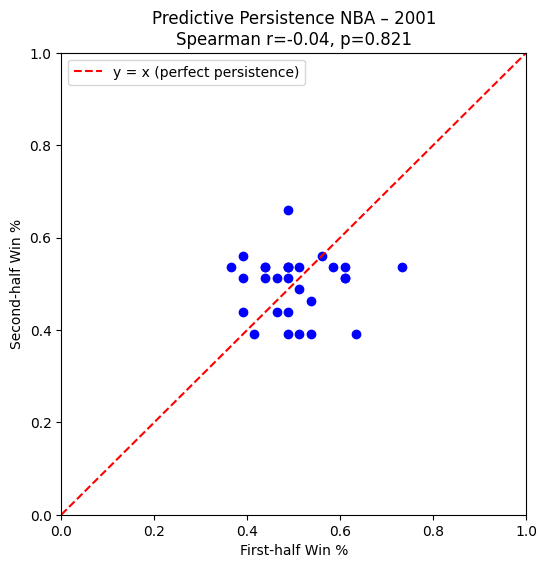

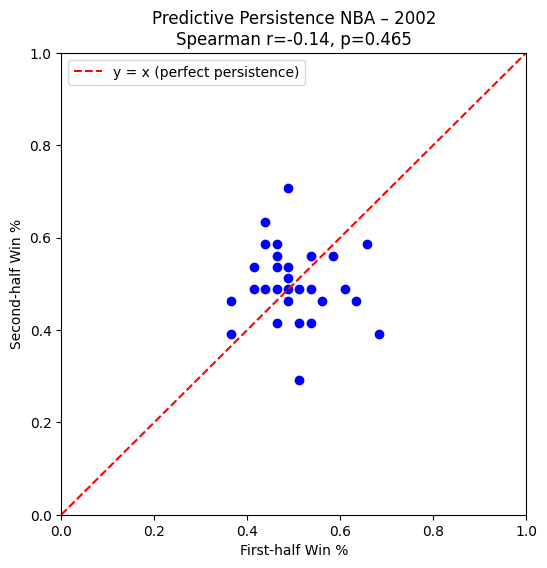

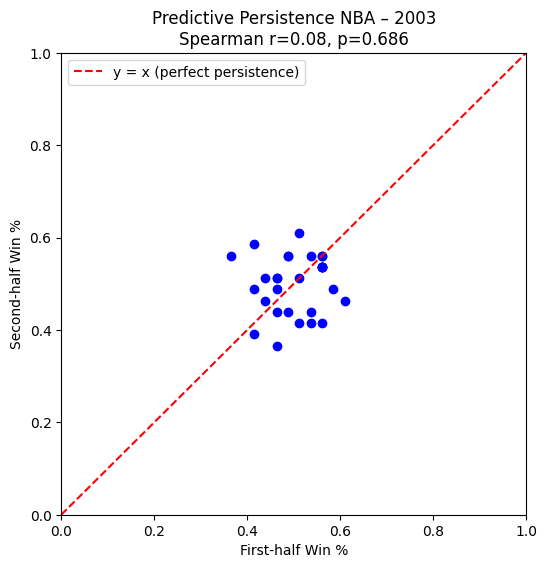

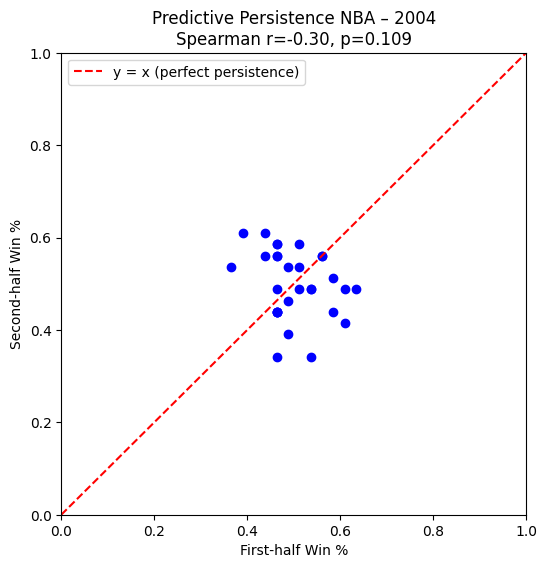

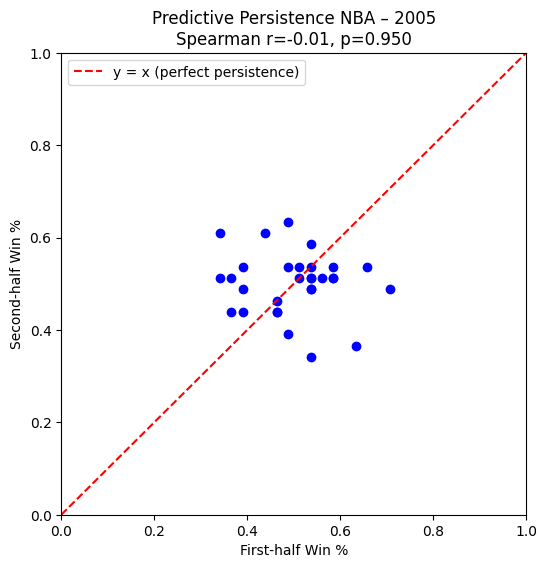

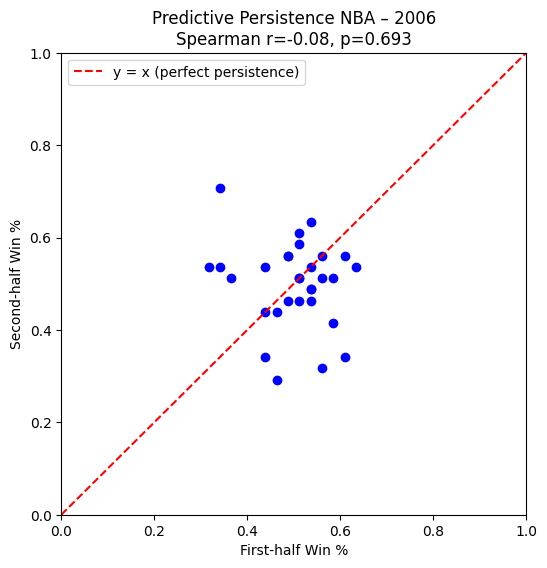

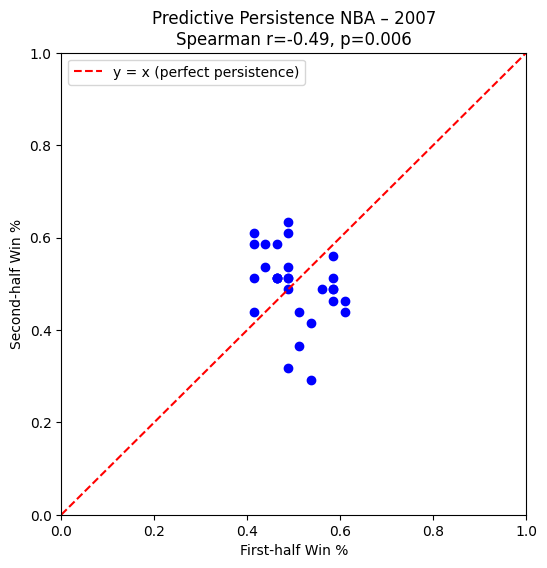

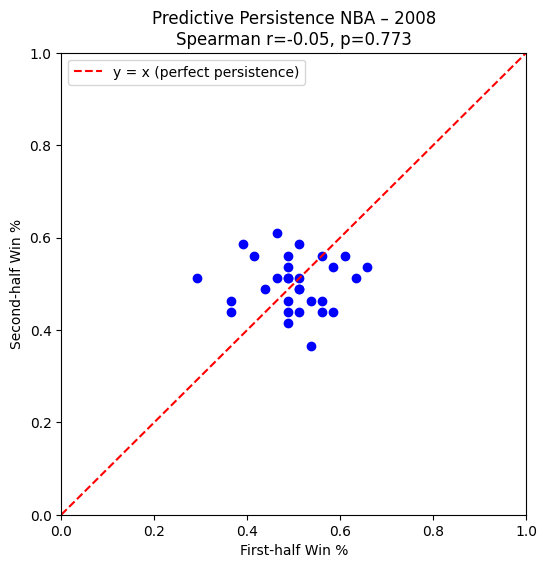

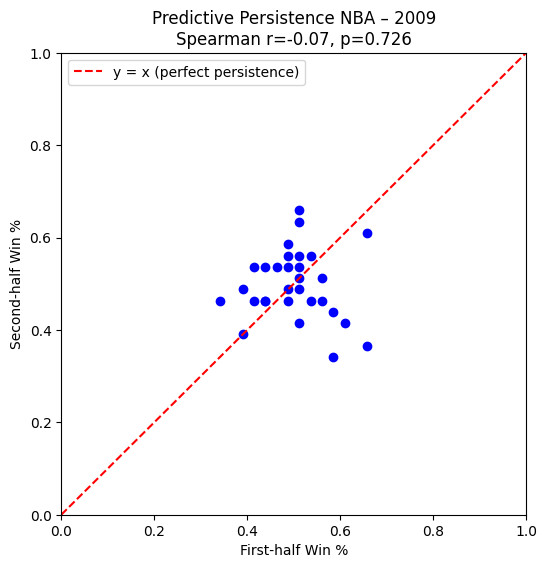

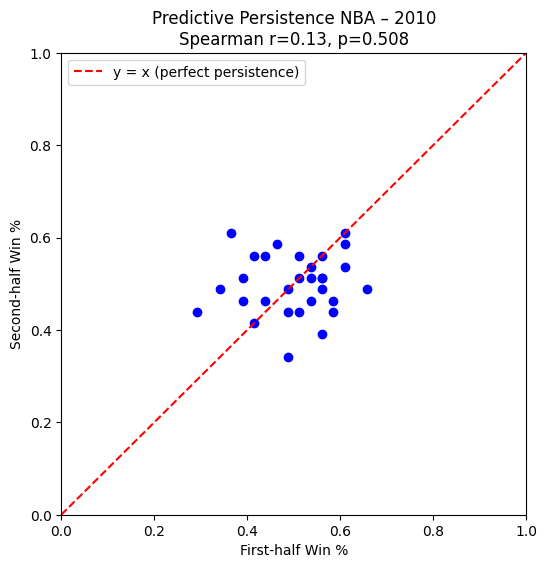

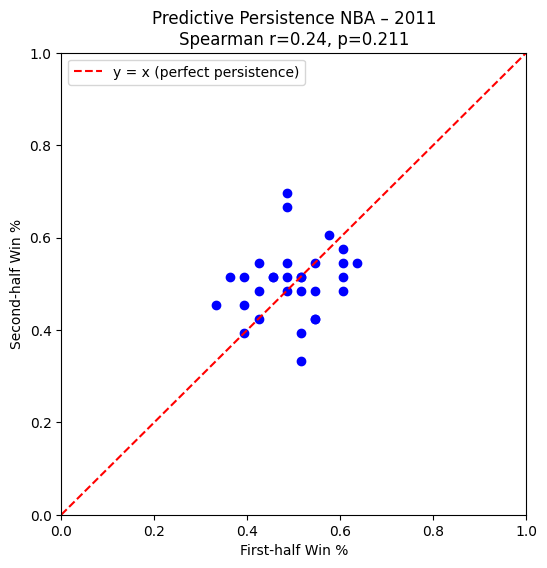

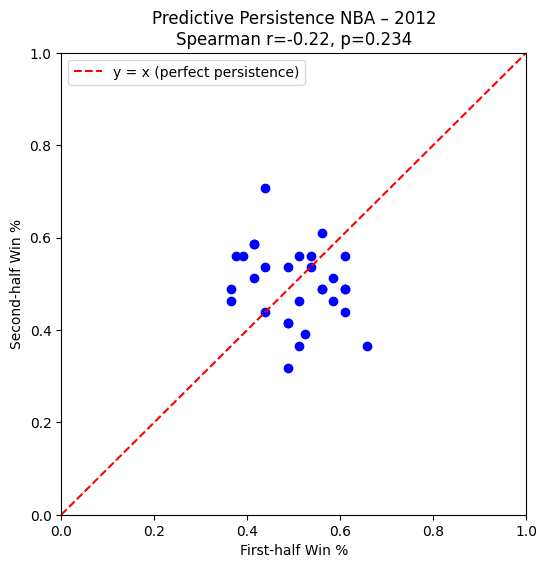

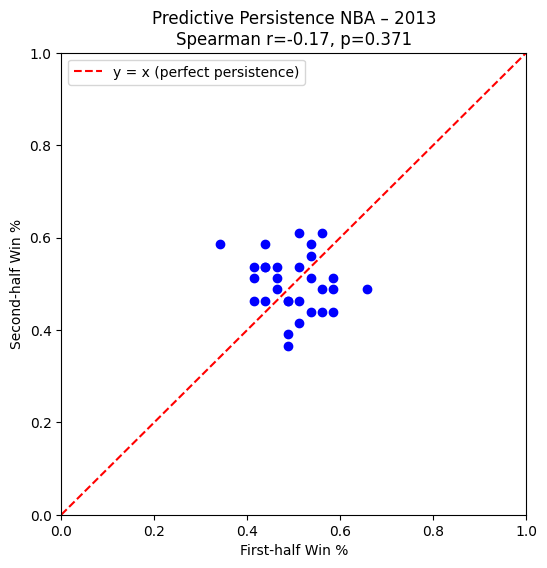

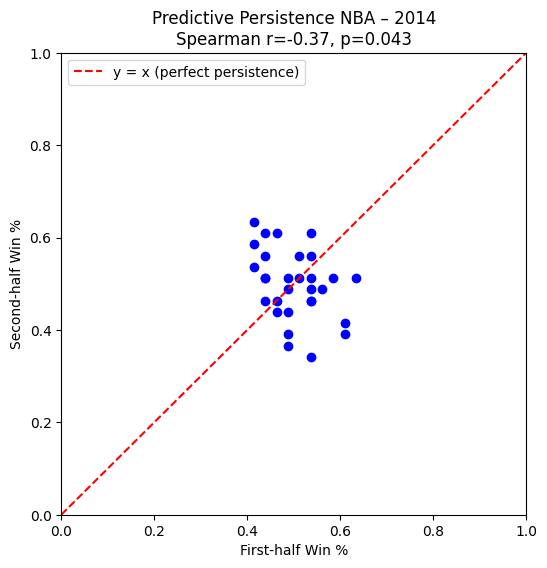

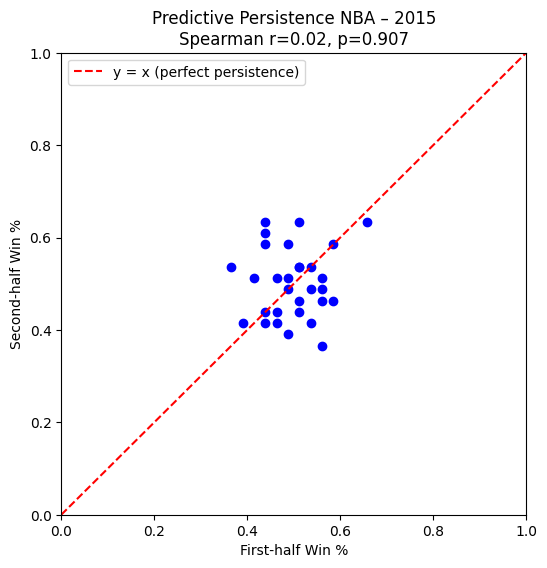

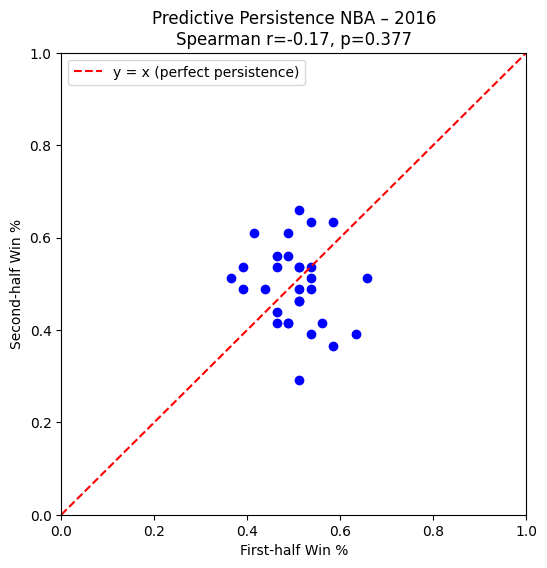

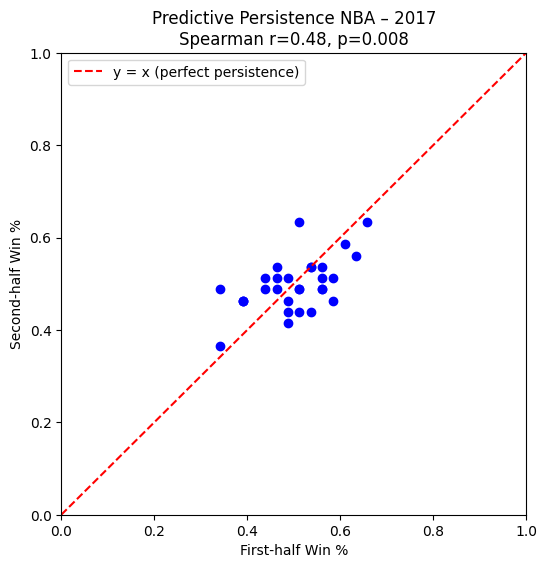

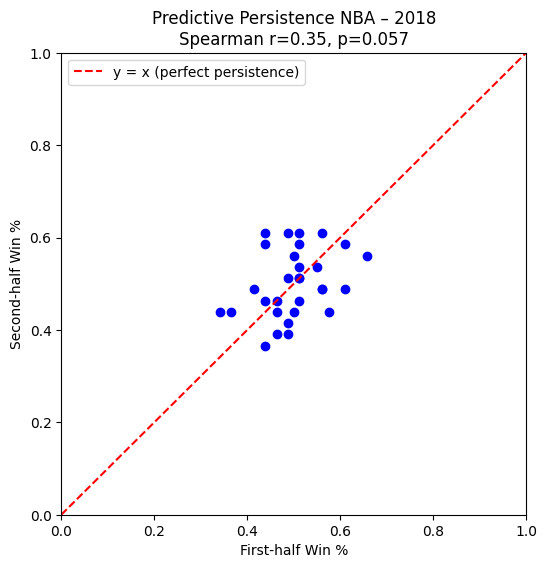

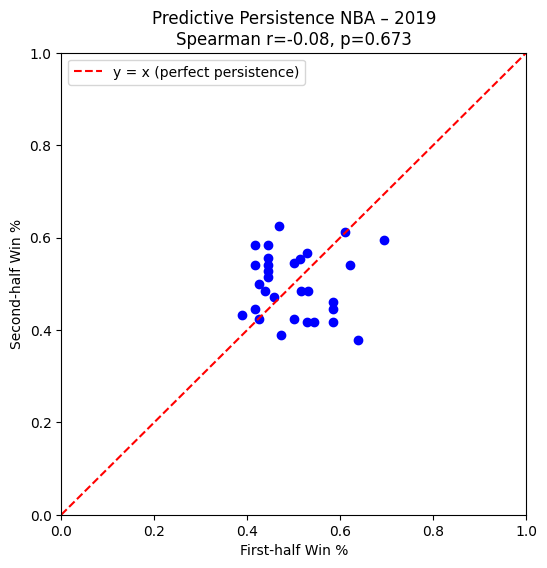

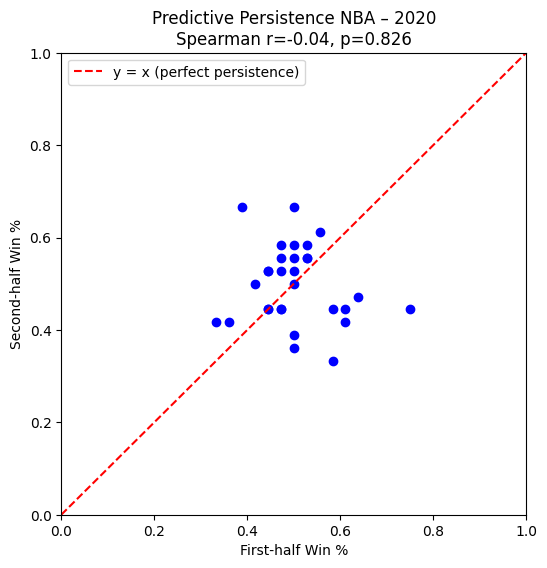

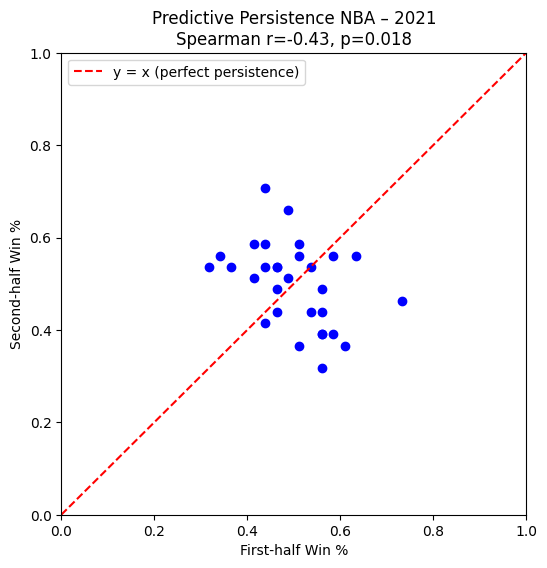

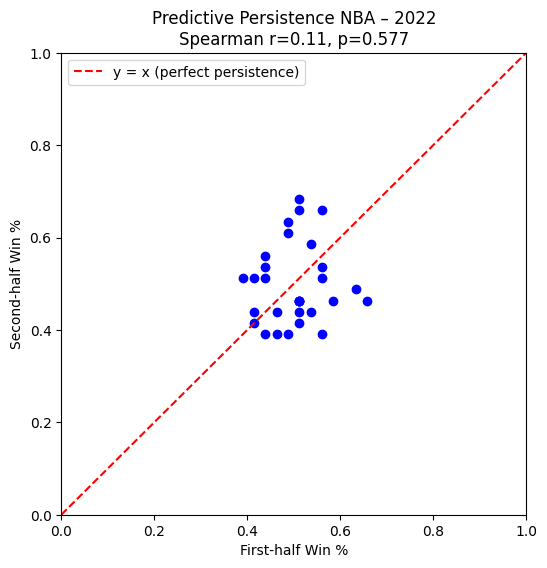

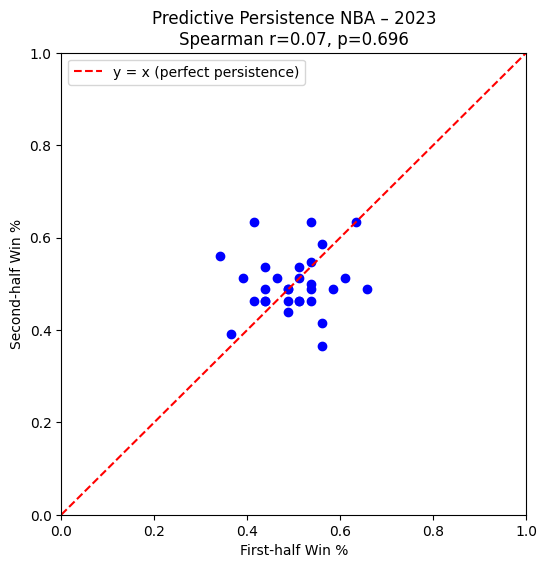

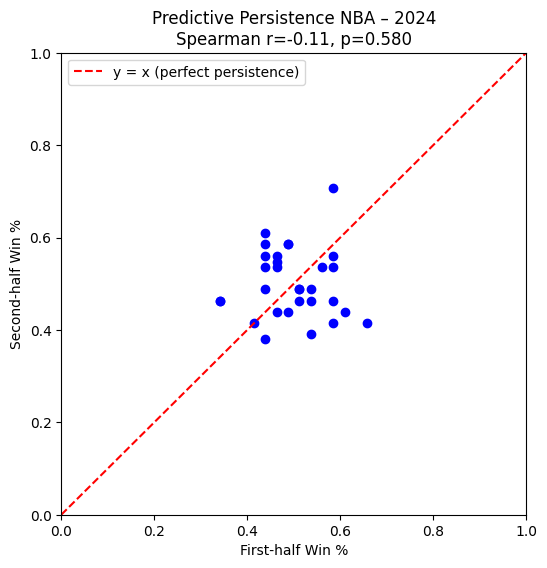

In [22]:
# ============================================================
# Predictive Persistence Analysis (NBA dataset)
# ============================================================

# 0) Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.ticker as mtick

# ------------------------------------------------------------
# 1) Load the dataset: NBA
# ------------------------------------------------------------

prob = 0.7  # set 0.5, 0.7, 0.8, etc.
DATA_PATH = f'us_combined_data_coin_flip_{prob:.1f}.csv'

df = pd.read_csv(DATA_PATH)
df = df[df['league'] == 'NBA']
df['date'] = pd.to_datetime(df['date'])


# ------------------------------------------------------------
# 2) Convert into "team-game" format
# We build a table where each original game row
# is viewed from one of the team's point of view.
# Then we can look at, for each team, a section in the table which
# represents their wins and losses throughout the season
# ------------------------------------------------------------

## Team1 Perspective ##
t1 = pd.DataFrame({
    'season': df['season'],
    'date': df['date'],
    'team': df['team1'],
    'opponent': df['team2'],
    'points_for': df['score1'],
    'points_against': df['score2'],
})
# add team's point differential for each game
t1['margin'] = t1['points_for'] - t1['points_against']
# add team's win flag for each game. 1 = win, 0 = loss
t1['win'] = (t1['margin'] > 0).astype(int)

## Team2 Perspective ##
t2 = pd.DataFrame({
    'season': df['season'],
    'date': df['date'],
    'team': df['team2'],
    'opponent': df['team1'],
    'points_for': df['score2'],
    'points_against': df['score1'],
})
# add team's point differential for each game
t2['margin'] = t2['points_for'] - t2['points_against']
# add team's win flag for each game 1 = win, 0 = loss
t2['win'] = (t2['margin'] > 0).astype(int)

# Combine both perspectives
# Make a single table with one row per team per game
# (each real game appears twice: once for each team’s perspective).

# stacks rows, and then reindexes the rows to go from row 0 to row N-1
team_games = pd.concat([t1, t2], ignore_index=True)
# reorders rows so they are grouped by season, then by team, then by date
# reindexes the rows to go from row 0 to row N-1, delete old row lab\
team_games = team_games.sort_values(['season','team','date']).reset_index(drop=True)

# ------------------------------------------------------------
# 3) Helper functions
# ------------------------------------------------------------

# define function which takes in the team games, and returns, for
# each season and team, the team's first-half and second-half win percentages
def compute_first_second_halves(team_games):
    rows = [] # initializes an empty list
    # for loop groups team_games by season and team, where
    # (season, team) is the current group key, and
    # grp is a DataFrame containing only that team's rows in the season
    for (season, team), grp in team_games.groupby(['season','team']):
        grp = grp.sort_values('date') # sorts grp by date
        n = len(grp)
        if n < 2: # if game has < 2 games, can't split into halves, so skip
            continue
        split = n // 2 # gives index at which to split the season into two halves
        first = grp.iloc[:split] # take first split rows as first half
        second = grp.iloc[split:]# take second split rows as second half
        if len(first) == 0 or len(second) == 0: # if n was 1, skip
            continue
        m1, m2 = first['win'].mean(), second['win'].mean() # mean = fraction of wins
        # store summary row for this (seaosn, team)
        rows.append({'season': season, 'team': team,
                     'first': m1, 'second': m2,
                     'n_games': n})
    # return the collected list of dictionaries into a DataFrame with cols
    # season, team, first, second, n_games
    return pd.DataFrame(rows)

# define function which plots first-half and second-half win percentage
# for all teams in one season
def plot_season_scatter(grp, season):
    # compute Spearman rank correlation and p_value between first half and second half win percentage
    r_s, p_s = stats.spearmanr(grp['first'], grp['second'])
    plt.figure(figsize=(6,6)) # creates square figure
    plt.scatter(grp['first'], grp['second'], color='blue') # plots one point per team
    # draw y = x line
    xs = np.linspace(0, 1, 100)
    plt.plot(xs, xs, linestyle='--', color='red', label='y = x (perfect persistence)')
    # fix x and y axis to [0,1], label axes, title graph
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('First-half Win %')
    plt.ylabel('Second-half Win %')
    plt.title(f'Predictive Persistence NBA – {season}\nSpearman r={r_s:.2f}, p={p_s:.3f}')
    plt.legend() # shows label on y = x line
    plt.show()

# define function which takes output of compute_first_second_halves (one row per team-season
# with 'first' and 'second' win percentages) and computes a per-season Spearman correlation.
def season_correlations(first_second_df):
    out = []  # collect one dict per season with Spearman stats
    for season, grp in first_second_df.groupby('season'):
        # Need variation and enough teams; otherwise correlation is undefined or meaningless
        if grp['first'].nunique() <= 1 or grp['second'].nunique() <= 1 or len(grp) < 3:
            continue
          # rank each array
        r_s, p_s = stats.spearmanr(grp['first'], grp['second'])
        out.append({
            'season': season,
            'n_teams': len(grp),
            'spearman_r': r_s,
            'spearman_p': p_s
        })
      # store stats for the season: number of teams,
      # spearman r-val (correlation between first half and second half win %
      # across teams in that season), p-val
    return pd.DataFrame(out).sort_values('season')


# ------------------------------------------------------------
# 4) Run predictive persistence analysis
# ------------------------------------------------------------

# get per team per season summaries
fs_win = compute_first_second_halves(team_games)
# give the summaries to the correlation helper
corr_win = season_correlations(fs_win)


# ------------------------------------------------------------
# 5) One combined plot with ALL seasons overlaid
#    Title format: "Predictive Persistence NBA - [lowest season - highest season]"
# ------------------------------------------------------------

if not fs_win.empty:
    min_season = int(fs_win['season'].min())
    max_season = int(fs_win['season'].max())

    plt.figure(figsize=(7,7))
    # Overlay each season's points; label only if few seasons to avoid clutter
    for season, grp in fs_win.groupby('season'):
        plt.scatter(grp['first'], grp['second'], alpha=0.5, s=25, label=str(season))

    # create plot
    xs = np.linspace(0, 1, 100)
    plt.plot(xs, xs, linestyle='--', color='red', label='y = x (perfect persistence)')
    plt.xlim(0, 1)
    plt.ylim(0, 1)

    ax = plt.gca()
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    # axis labels for presentation
  #  plt.xlabel('First-half Win Percentage', fontsize=20)
  #  plt.ylabel('Second-half Win Percentage', fontsize=20)
    # end of axis labels for presentation
    # tick labels (optional)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    # end of tick labels for presentation
    plt.xlabel('First-half Win %') # commented out since small for presentation
    plt.ylabel('Second-half Win %') # commented out since small for presentation
    plt.title(f'NBA First-Half vs. Second-Half Coin Flip ({prob}) {min_season} - {max_season} Win Percentages') #temporarily comment out for presentation

    #  show labels only if the number of seasons is small
    if fs_win['season'].nunique() <= 15:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 6) Histogram of Spearman correlations across seasons
# ------------------------------------------------------------

if not corr_win.empty:
    plt.figure(figsize=(7,4))
    plt.hist(corr_win['spearman_r'].dropna(), bins=20)
    plt.title(f'Distribution of Spearman r across NBA seasons Coin Flip ({prob}) (Win %)')
    plt.xlabel('Spearman r')
    plt.ylabel('Count of seasons')
    plt.show()
    print("\nr value meanings:")
    print("r closer to 1: first half ranks are very predictive of second half ranks")
    print("r closer to 0: first half ranks are NOT very predictive of second half ranks")
    print("r negative: reverse tendency. high first half ranks predict low second half ranks, and vice versa")

# ------------------------------------------------------------
# 7) Plot scatterplots for ALL seasons
# ------------------------------------------------------------

for season, grp in fs_win.groupby('season'):
    if len(grp) >= 3: # don't print scatter plot if less than 3 teams
        plot_season_scatter(grp, season)


# Predictive Persistence Analysis (NFL dataset)


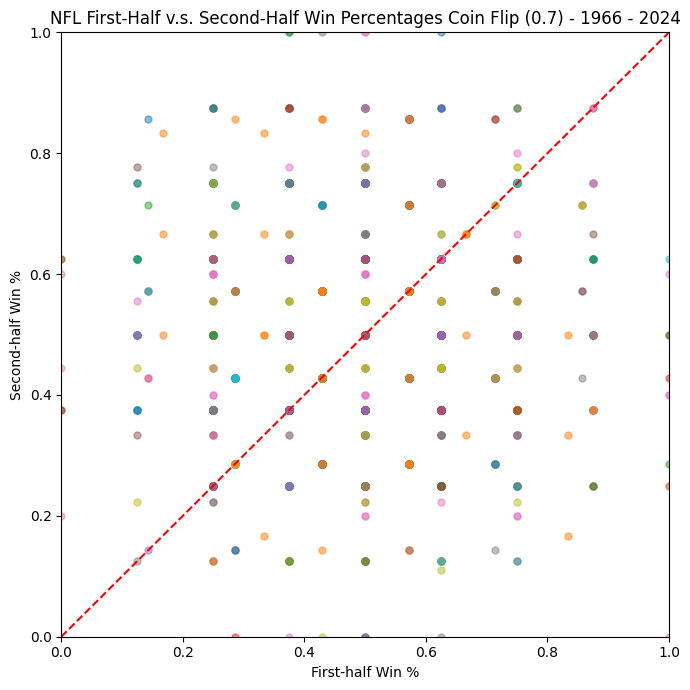

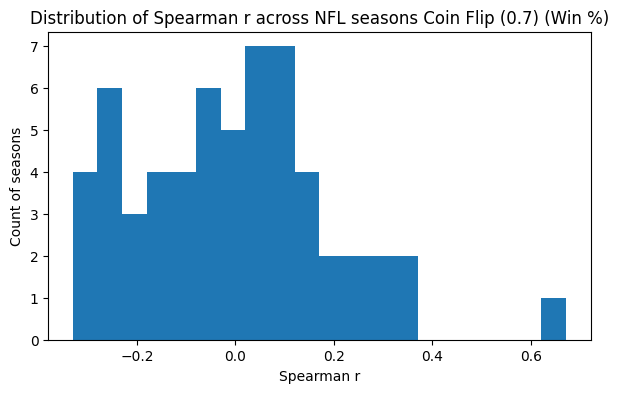


r value meanings:
r closer to 1: first half ranks are very predictive of second half ranks
r closer to 0: first half ranks are NOT very predictive of second half ranks
r negative: reverse tendency. high first half ranks predict low second half ranks, and vice versa


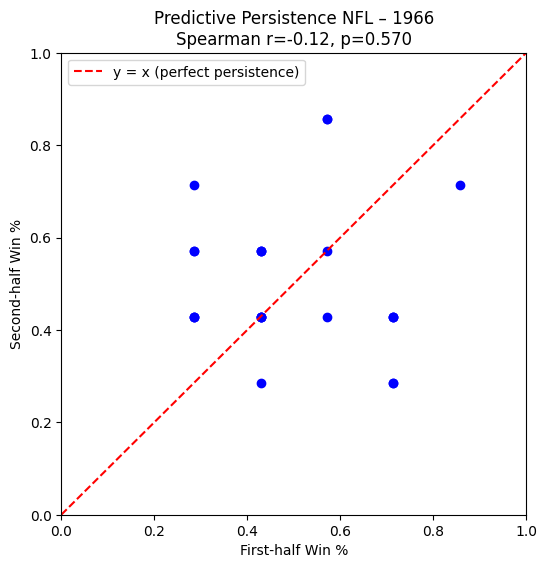

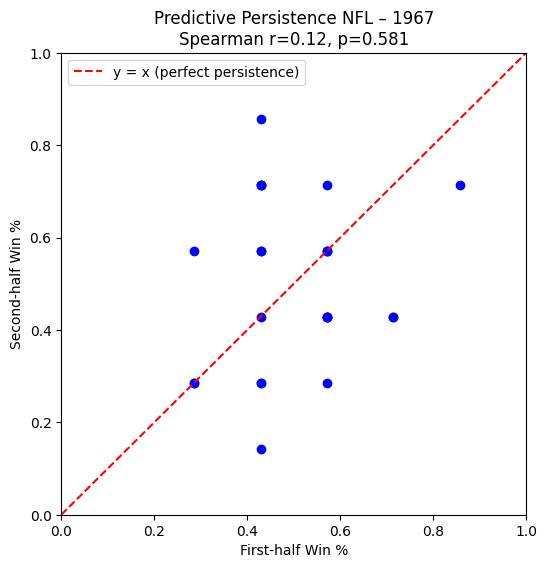

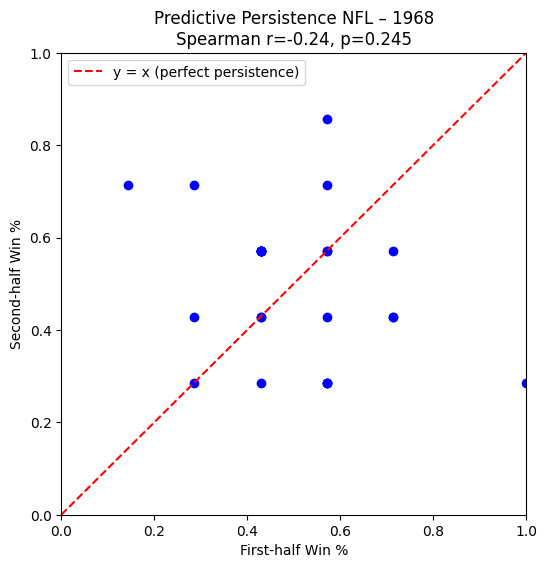

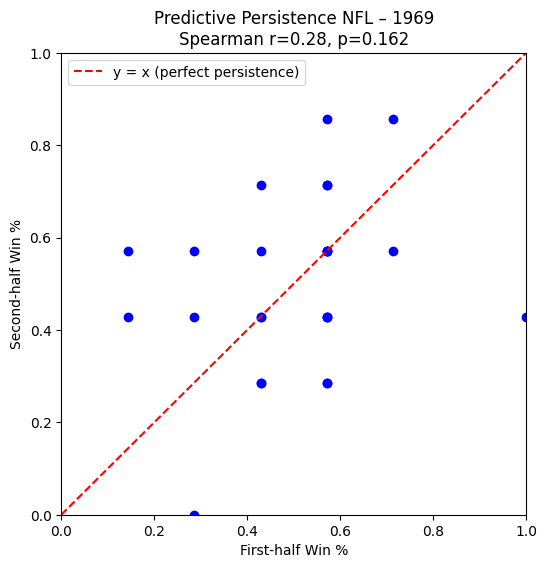

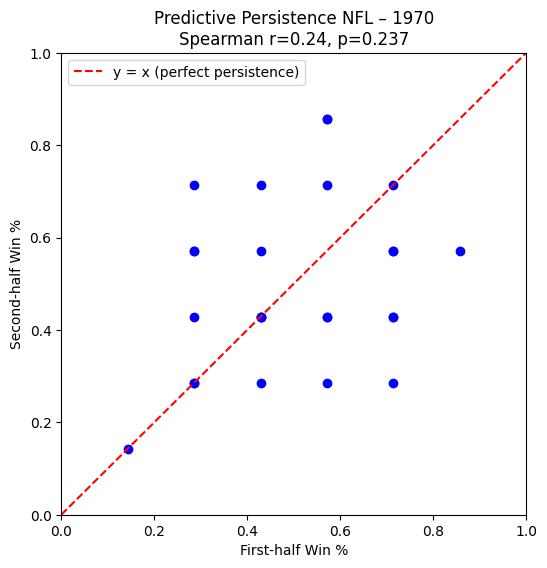

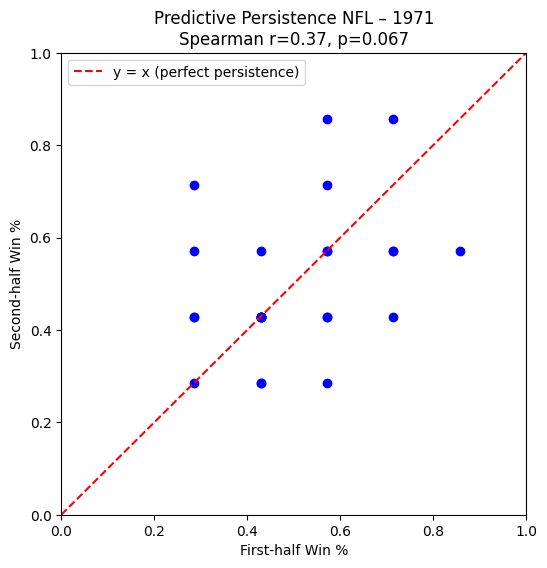

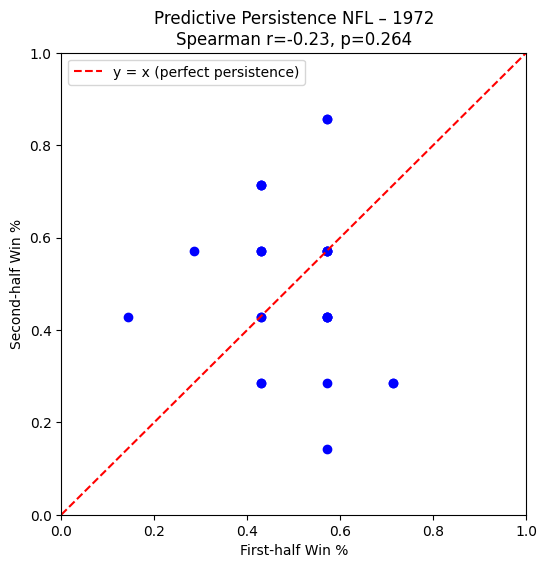

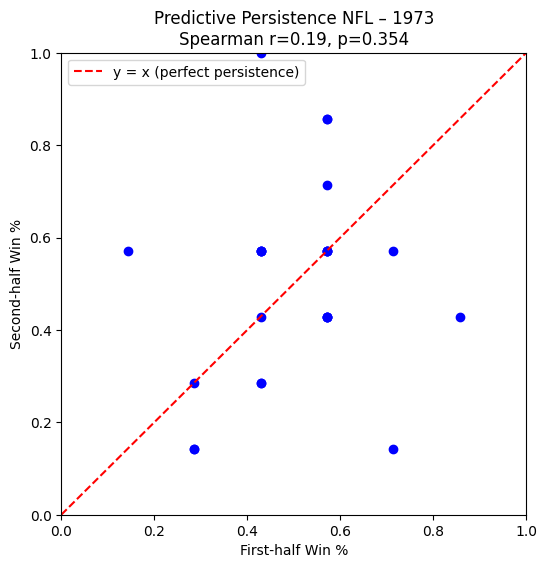

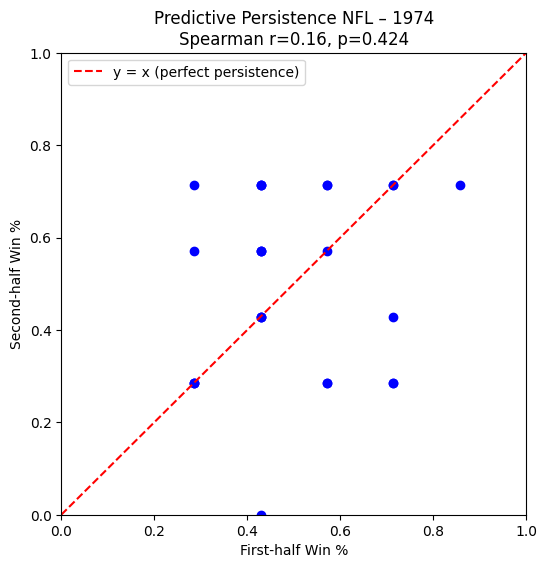

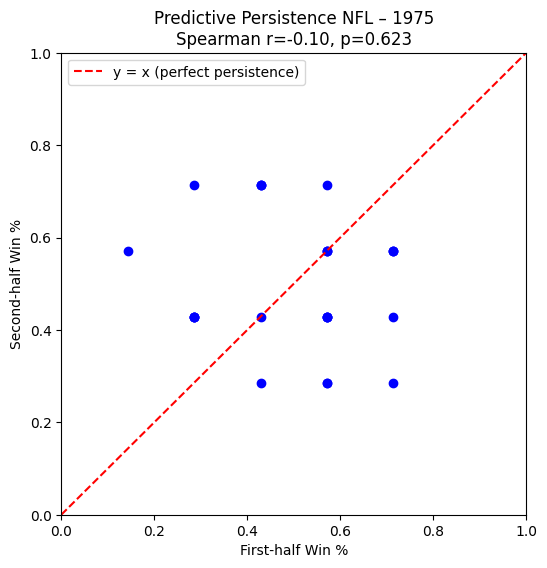

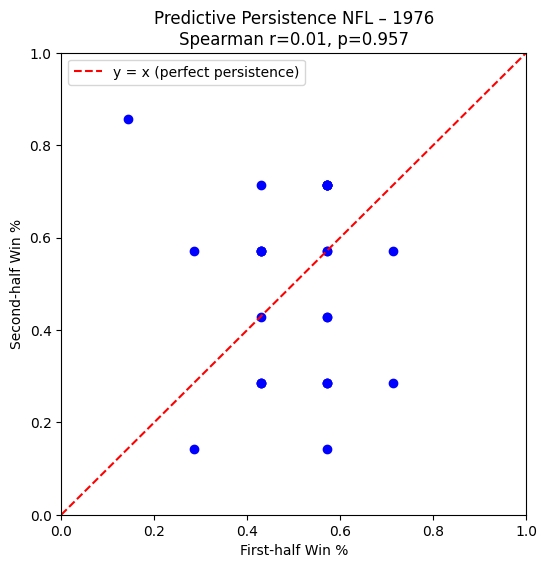

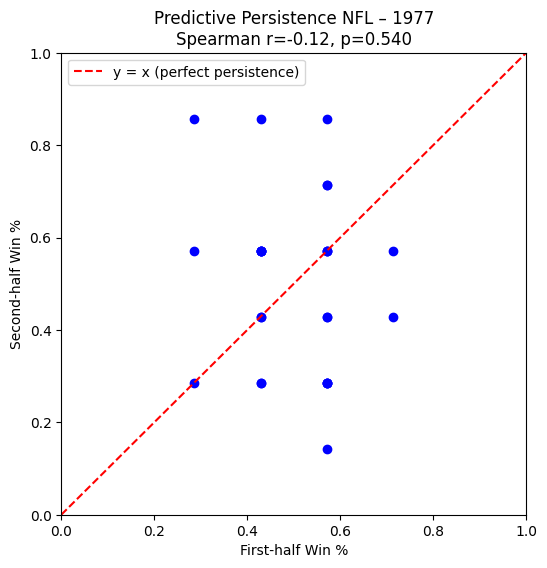

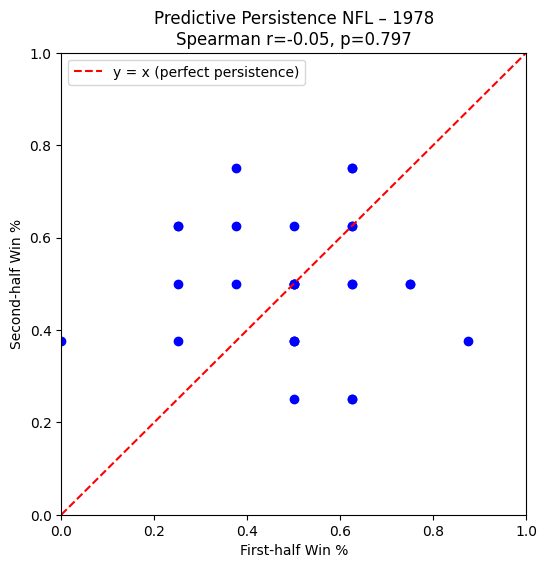

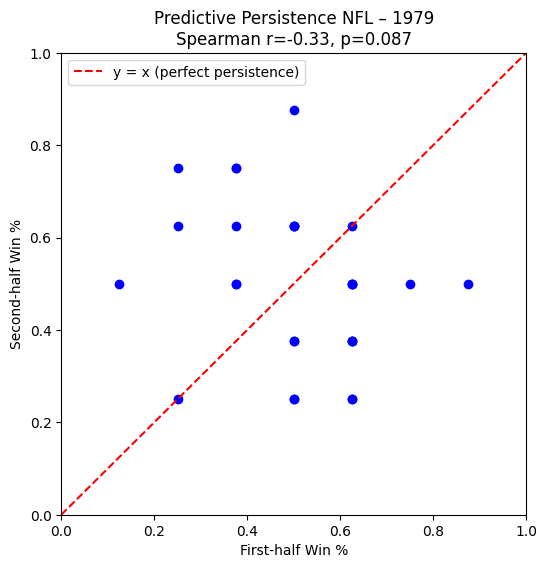

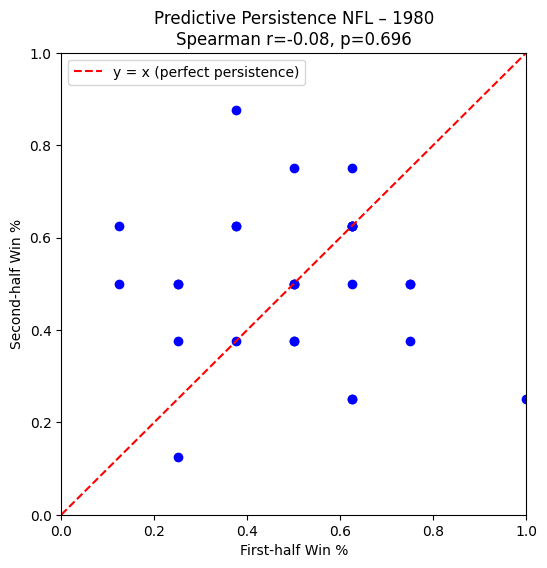

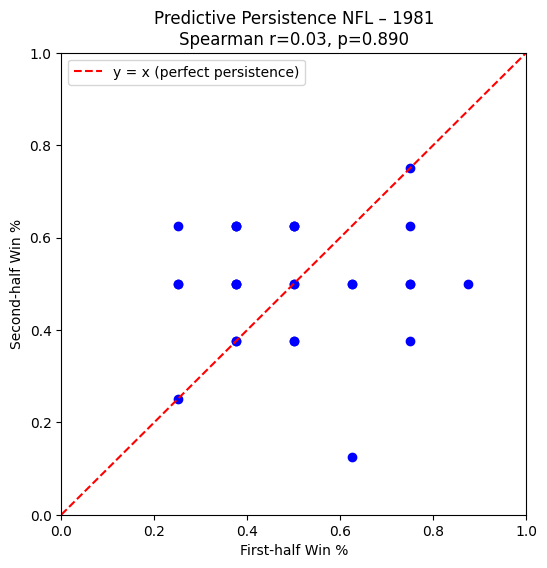

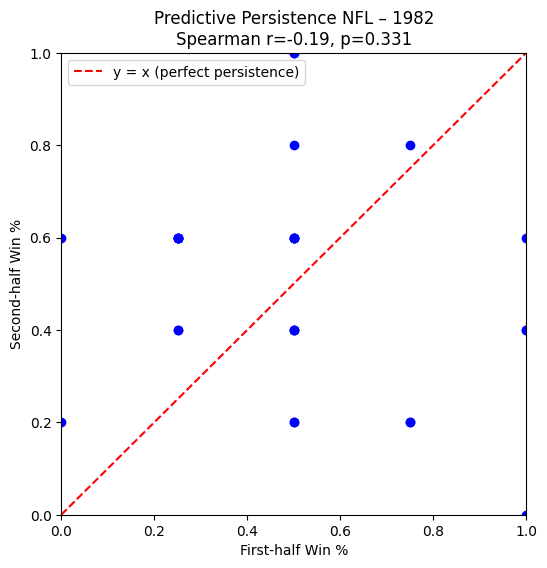

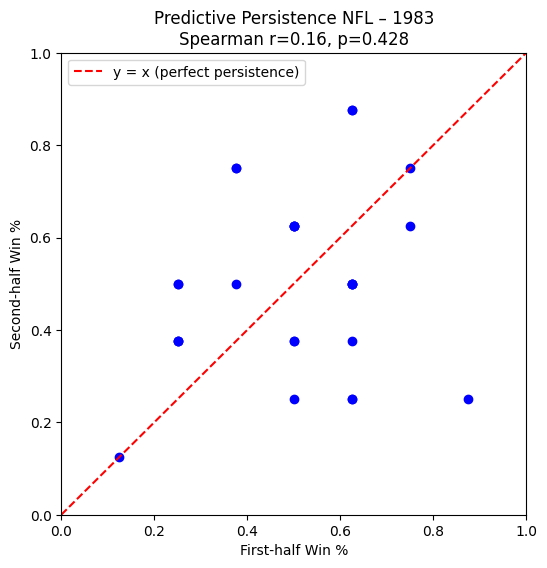

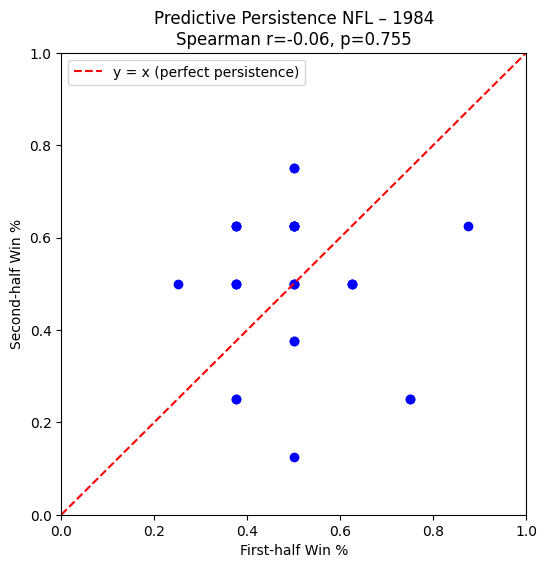

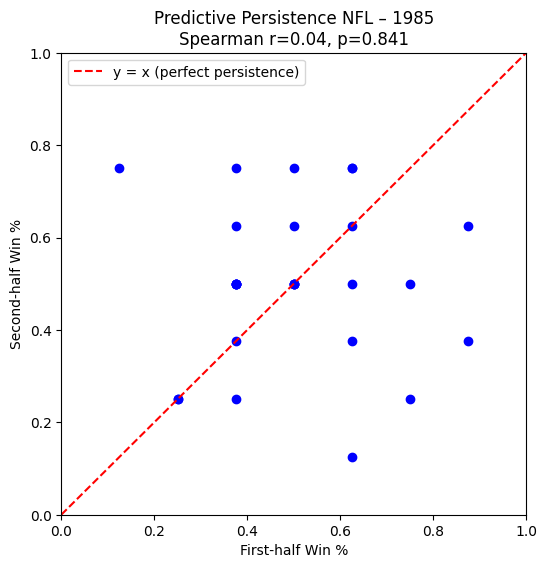

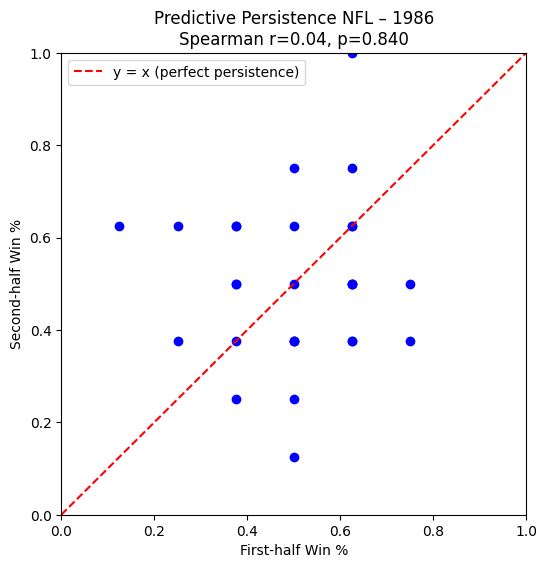

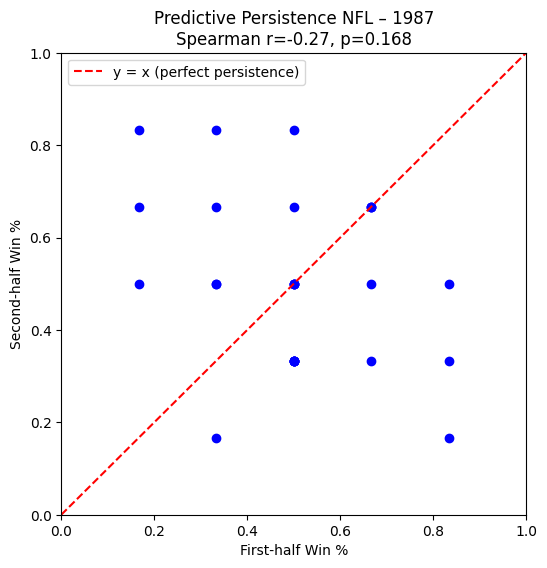

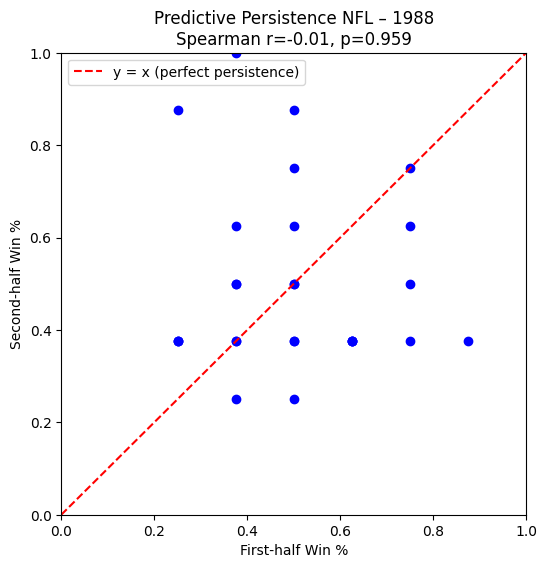

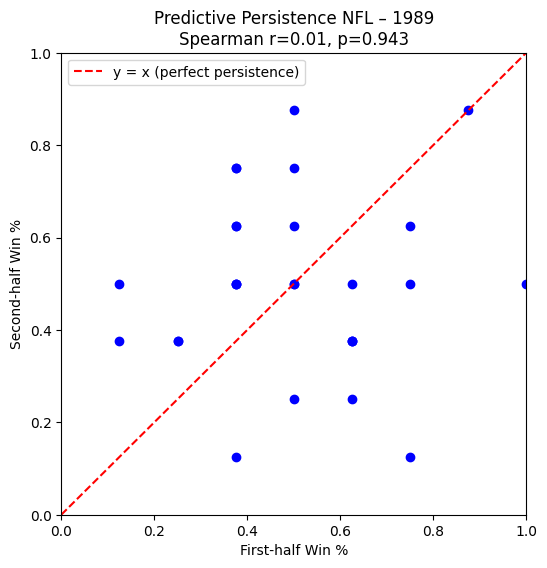

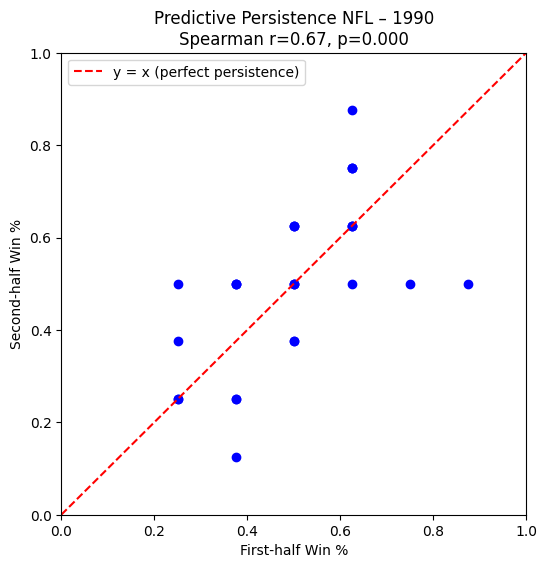

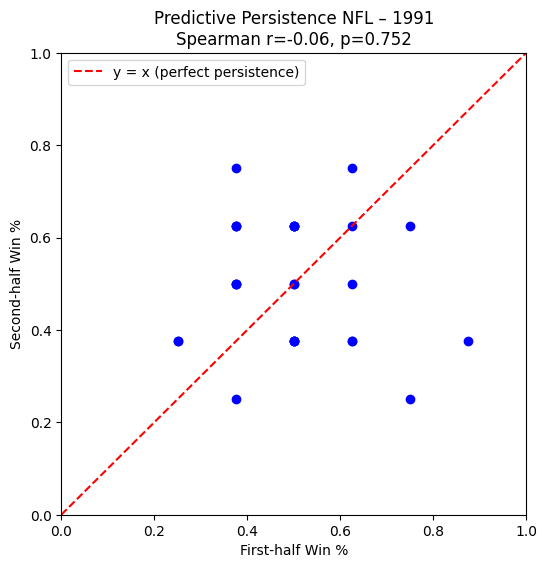

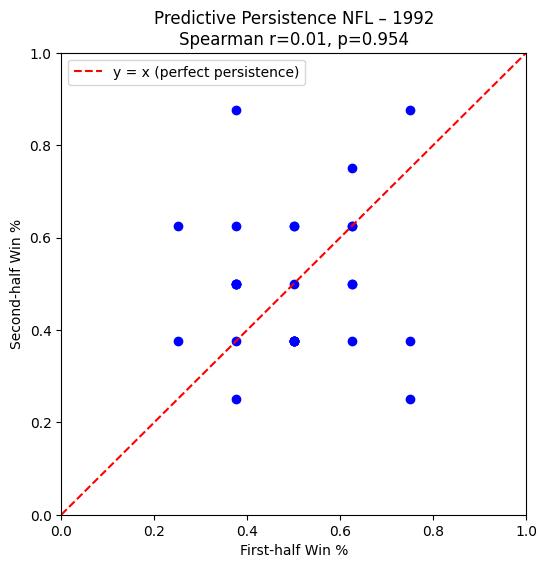

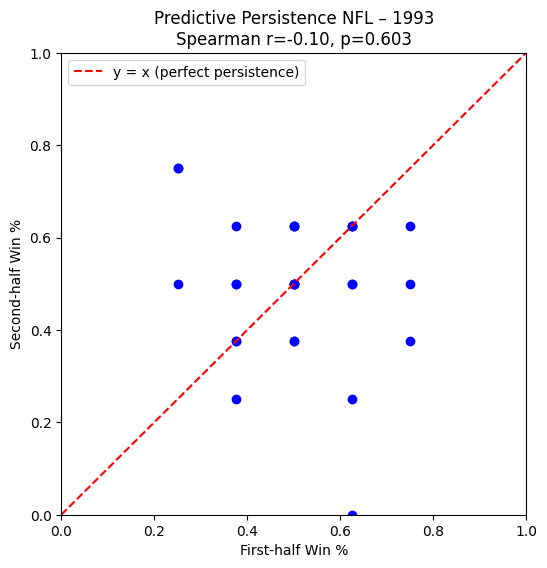

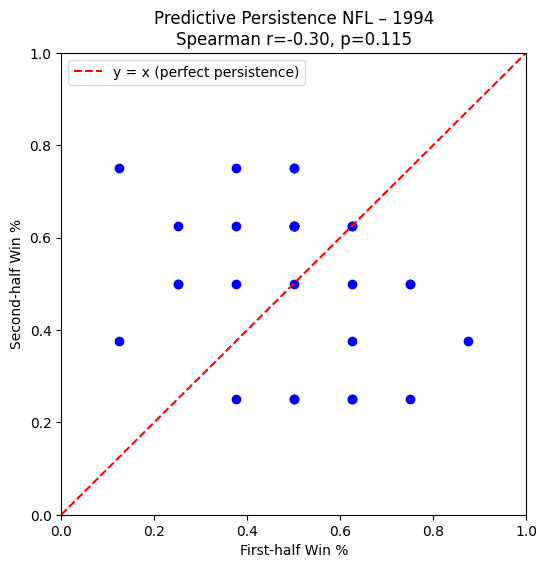

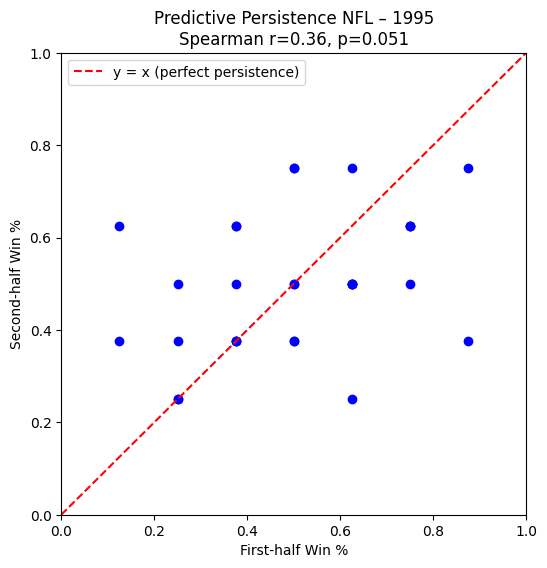

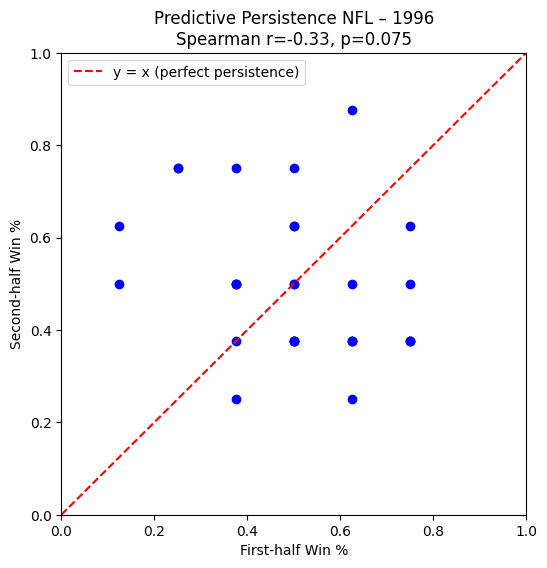

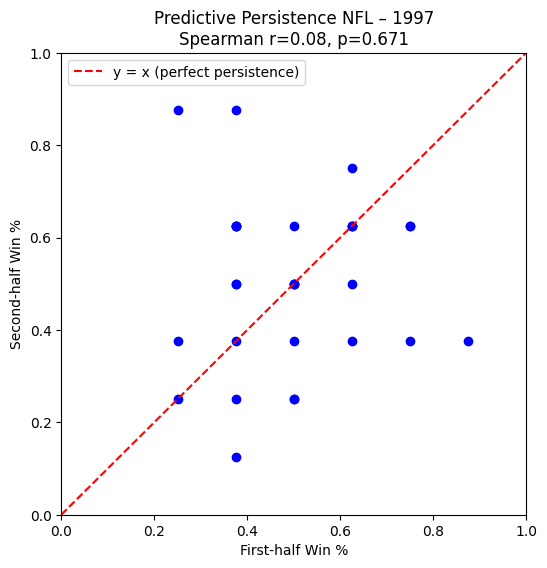

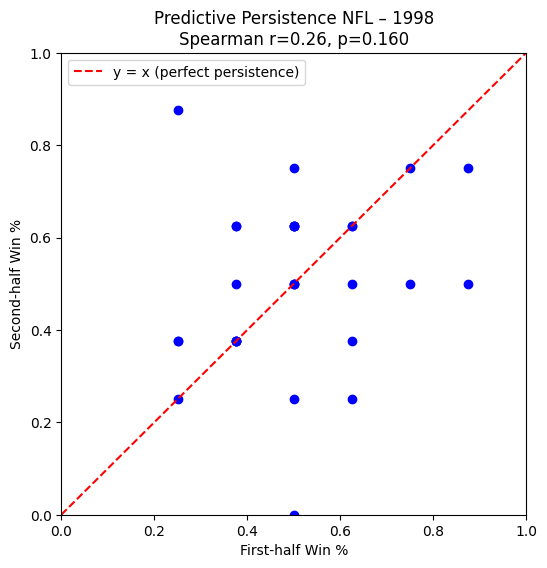

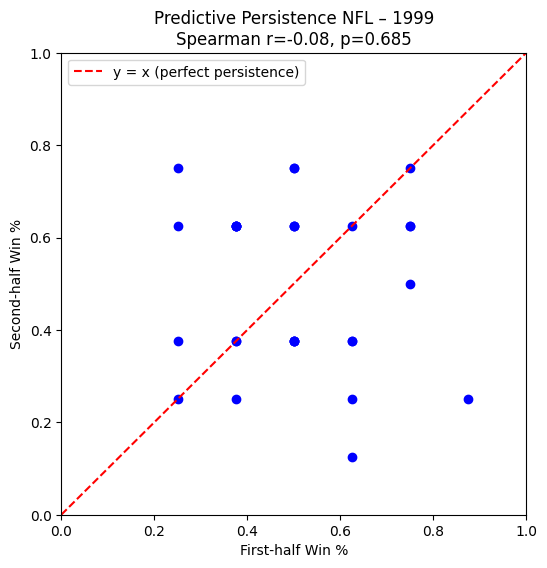

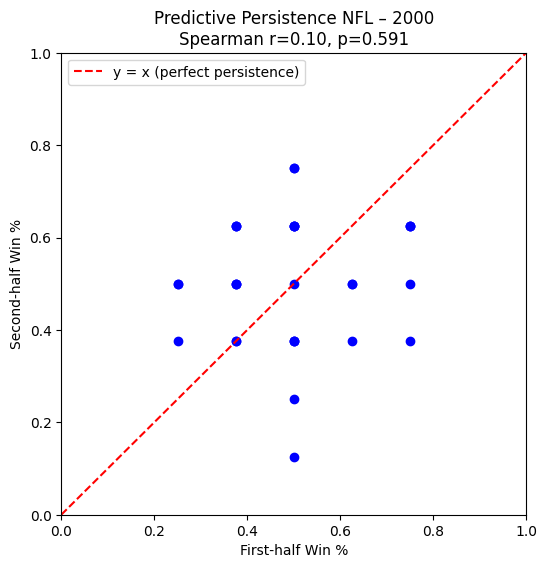

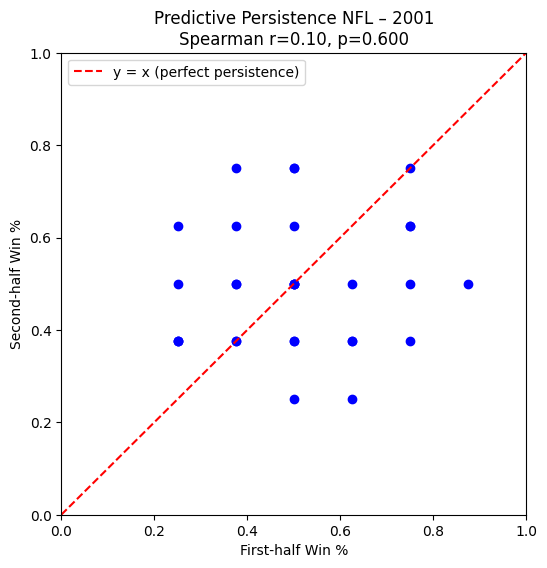

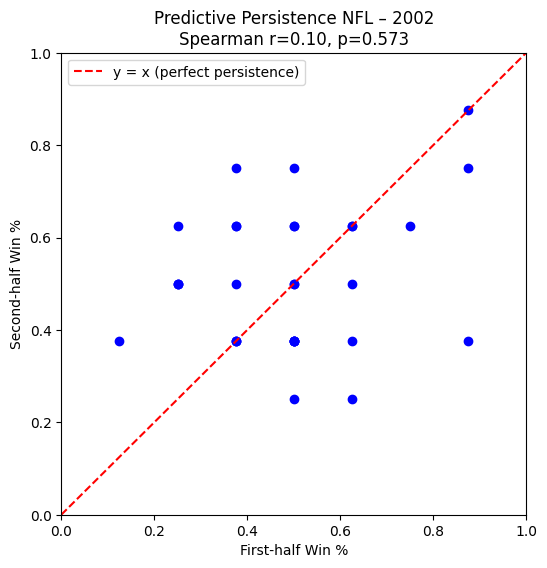

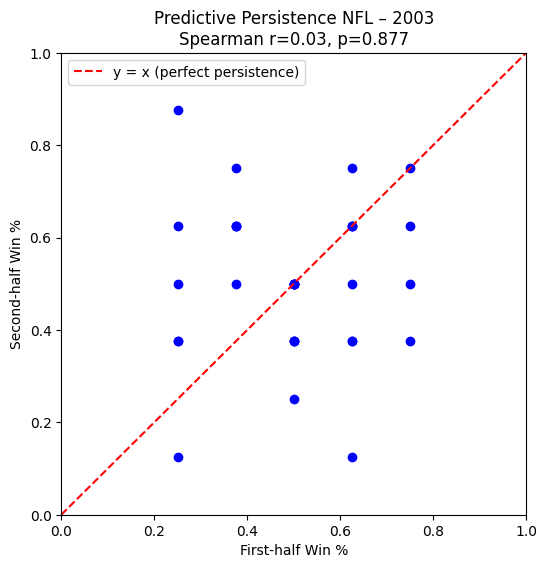

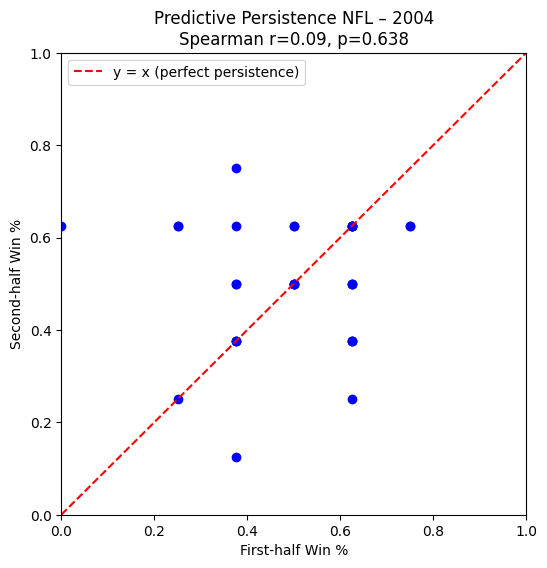

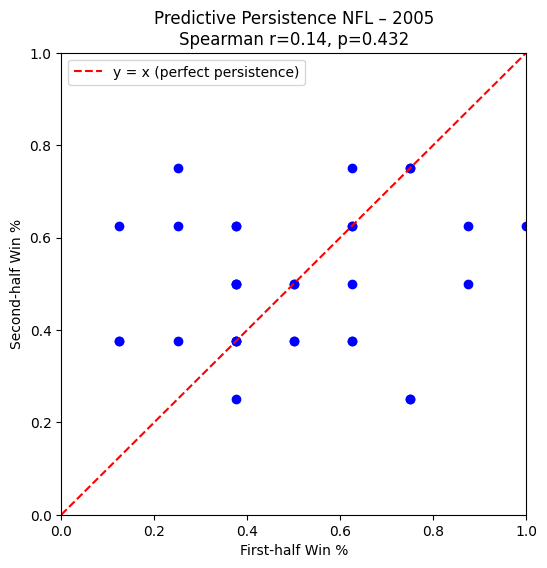

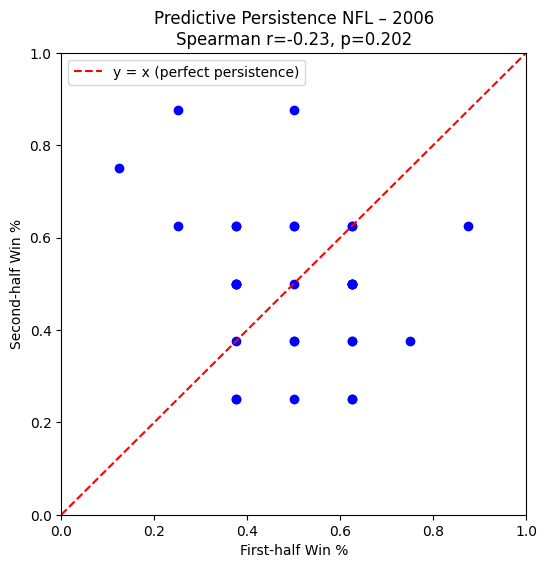

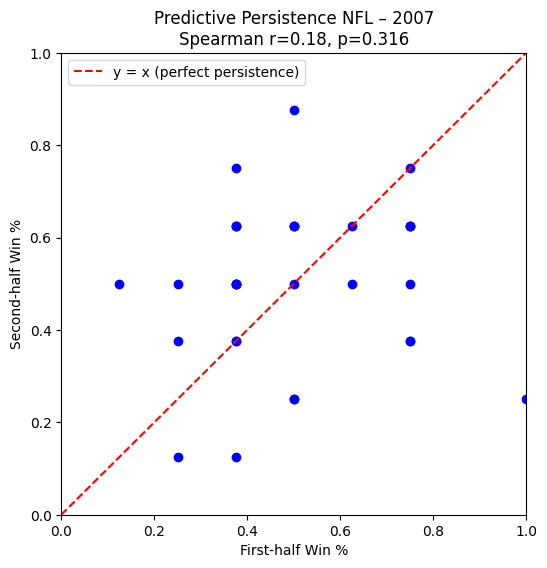

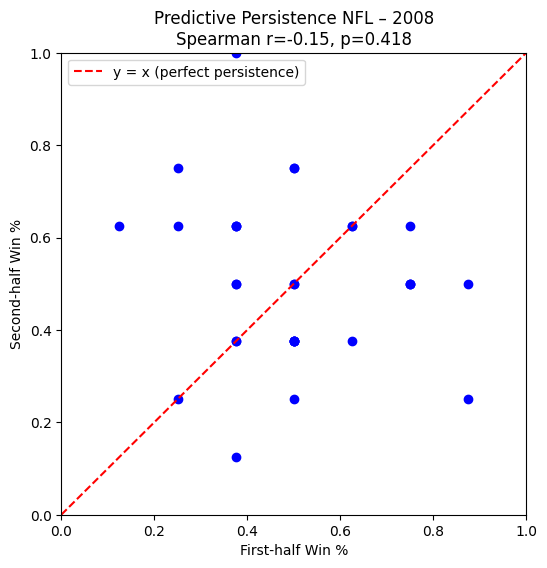

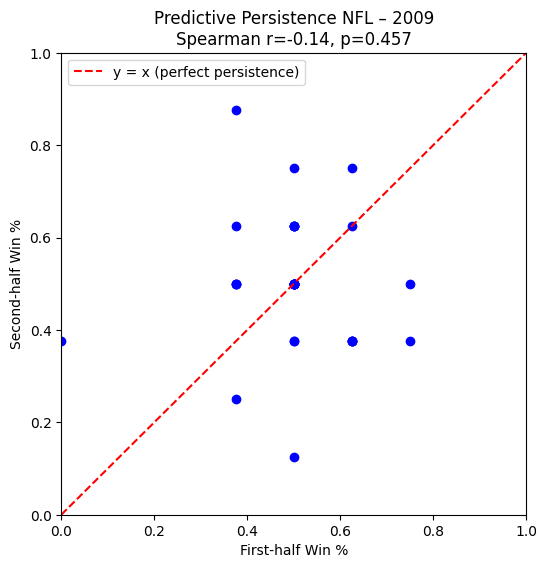

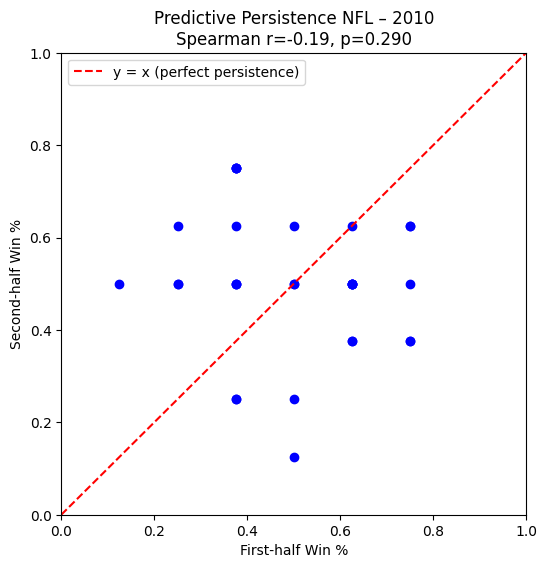

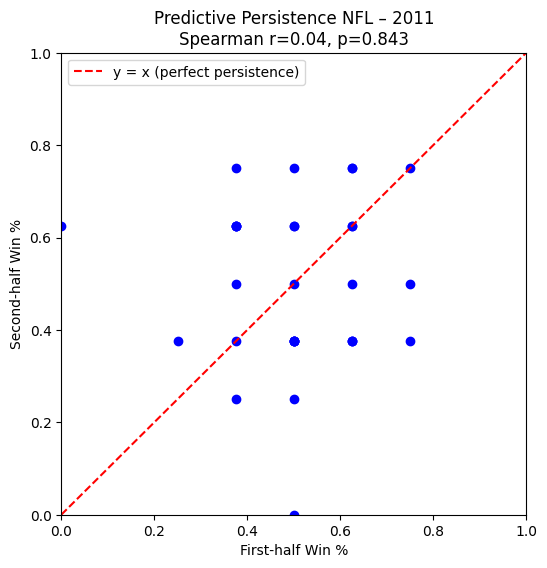

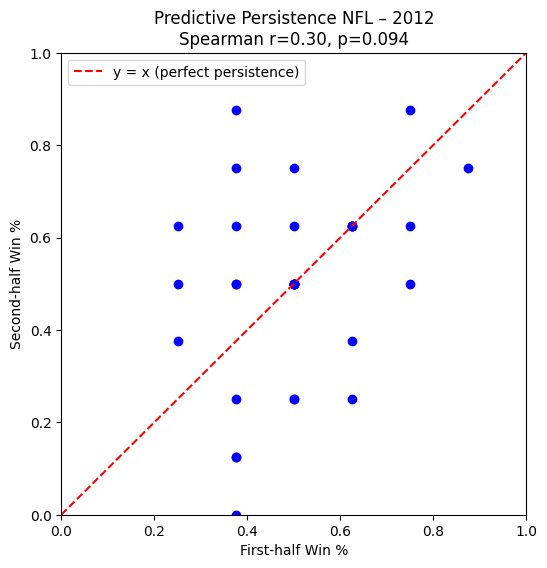

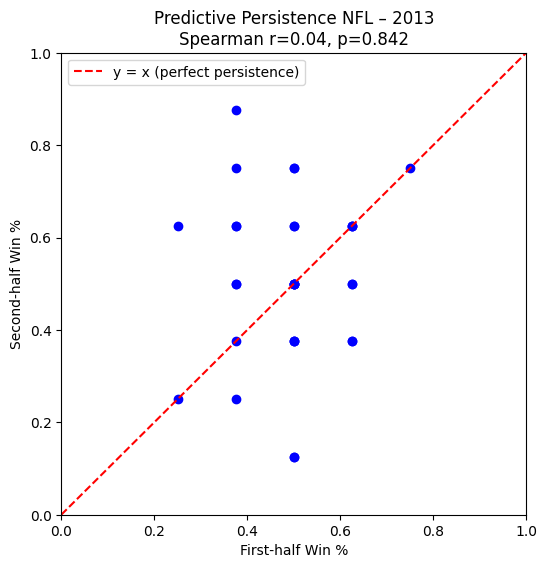

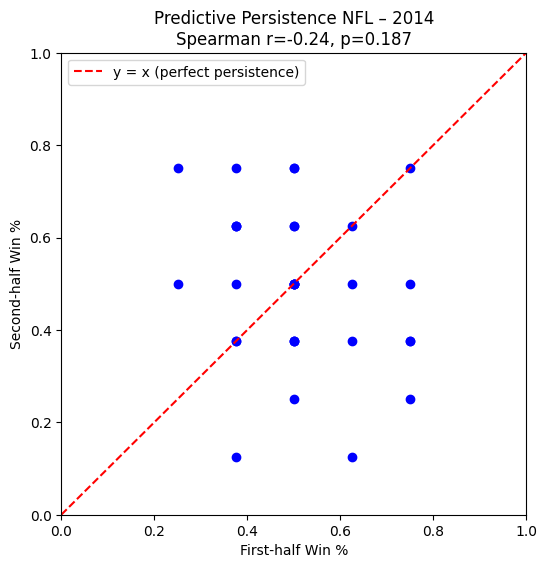

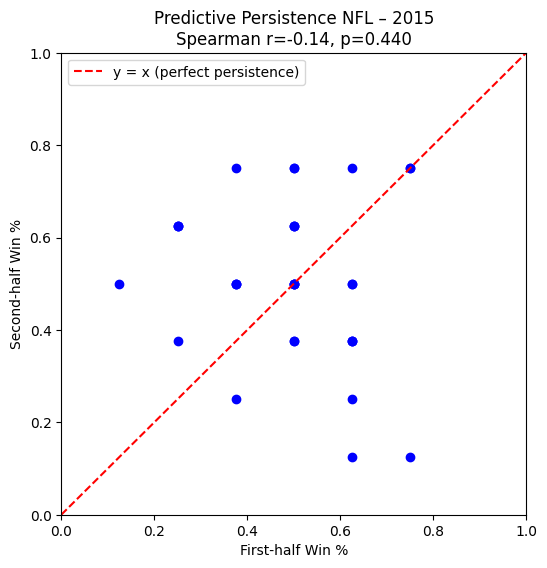

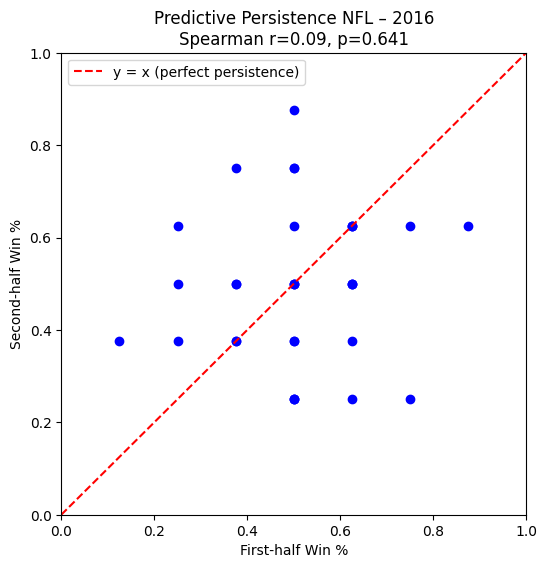

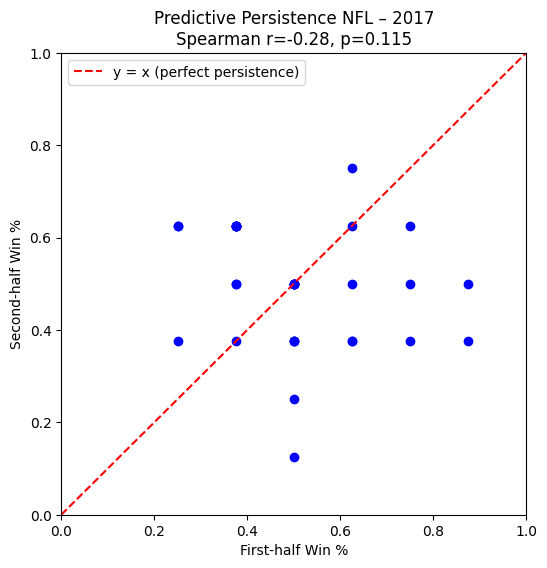

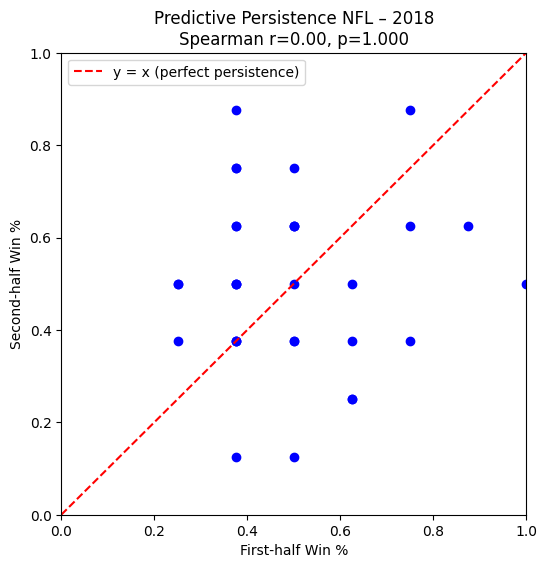

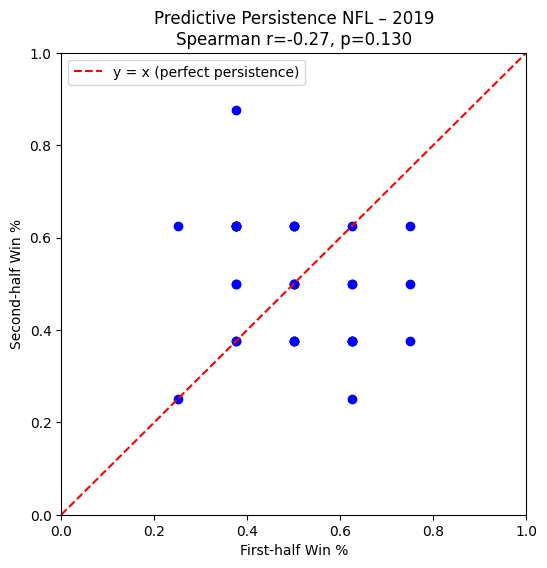

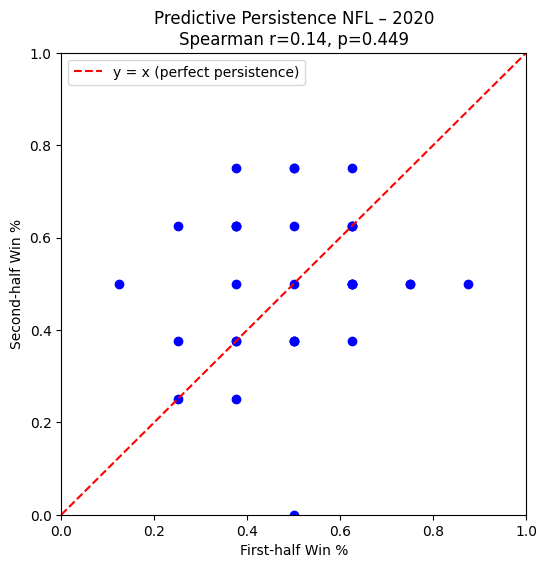

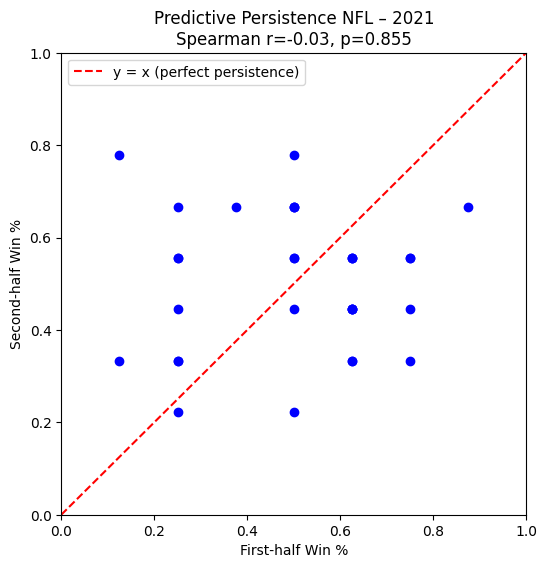

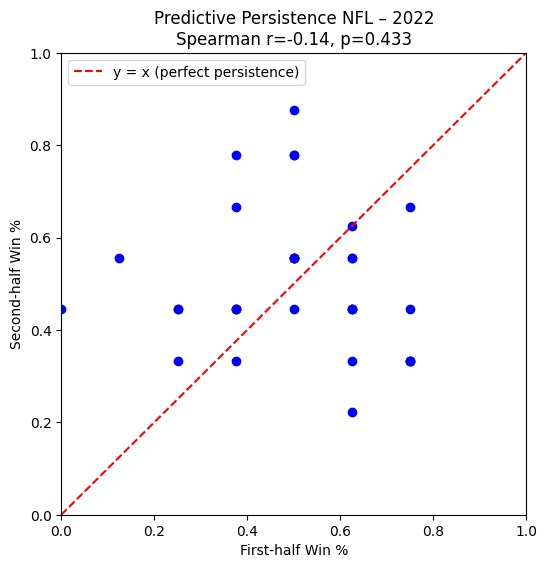

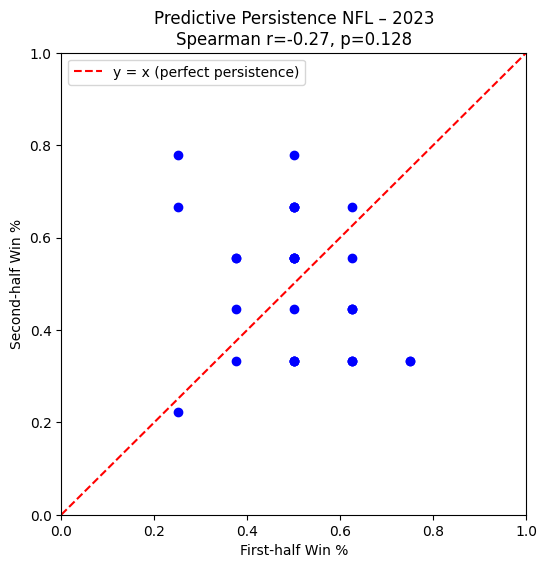

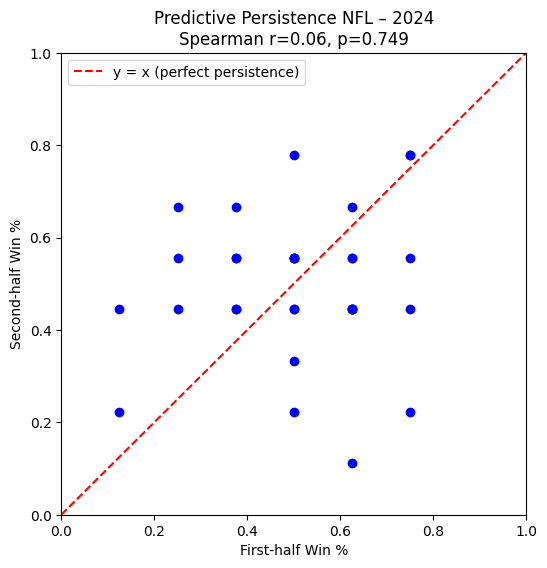

In [23]:
# ============================================================
# Predictive Persistence Analysis (NFL dataset)
# ============================================================

# 0) Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ------------------------------------------------------------
# 1) Load the dataset: NFL
# ------------------------------------------------------------

prob = 0.7  # set 0.5, 0.7, 0.8, etc.
DATA_PATH = f'us_combined_data_coin_flip_{prob:.1f}.csv'

df = pd.read_csv(DATA_PATH)
df = df[df['league'] == 'NFL']
df['date'] = pd.to_datetime(df['date'])

# ------------------------------------------------------------
# 2) Convert into "team-game" format
# We build a table where each original game row
# is viewed from one of the team's point of view.
# Then we can look at, for each team, a section in the table which
# represents their wins and losses throughout the season
# ------------------------------------------------------------

## Team1 Perspective ##
t1 = pd.DataFrame({
    'season': df['season'],
    'date': df['date'],
    'team': df['team1'],
    'opponent': df['team2'],
    'points_for': df['score1'],
    'points_against': df['score2'],
})
# add team's point differential for each game
t1['margin'] = t1['points_for'] - t1['points_against']
# add team's win flag for each game. 1 = win, 0 = loss
# (NFL): ties are possible; encode tie as 0.5 so averages reflect ties
t1['win'] = np.where(t1['margin'] > 0, 1,
                     np.where(t1['margin'] < 0, 0, 0.5))

## Team2 Perspective ##
t2 = pd.DataFrame({
    'season': df['season'],
    'date': df['date'],
    'team': df['team2'],
    'opponent': df['team1'],
    'points_for': df['score2'],
    'points_against': df['score1'],
})
# add team's point differential for each game
t2['margin'] = t2['points_for'] - t2['points_against']
# add team's win flag for each game 1 = win, 0 = loss
# (NFL): ties are possible; encode tie as 0.5 so averages reflect ties
t2['win'] = np.where(t2['margin'] > 0, 1,
                     np.where(t2['margin'] < 0, 0, 0.5))

# Combine both perspectives
# Make a single table with one row per team per game
# (each real game appears twice: once for each team’s perspective).

# stacks rows, and then reindexes the rows to go from row 0 to row N-1
team_games = pd.concat([t1, t2], ignore_index=True)
# reorders rows so they are grouped by season, then by team, then by date
# reindexes the rows to go from row 0 to row N-1, delete old row lab\
team_games = team_games.sort_values(['season','team','date']).reset_index(drop=True)

# ------------------------------------------------------------
# 3) Helper functions
# ------------------------------------------------------------

# define function which takes in the team games, and returns, for
# each season and team, the team's first-half and second-half win percentages
def compute_first_second_halves(team_games):
    rows = [] # initializes an empty list
    # for loop groups team_games by season and team, where
    # (season, team) is the current group key, and
    # grp is a DataFrame containing only that team's rows in the season
    for (season, team), grp in team_games.groupby(['season','team']):
        grp = grp.sort_values('date') # sorts grp by date
        n = len(grp)
        if n < 2: # if game has < 2 games, can't split into halves, so skip
            continue
        split = n // 2 # gives index at which to split the season into two halves
        first = grp.iloc[:split] # take first split rows as first half
        second = grp.iloc[split:]# take second split rows as second half
        if len(first) == 0 or len(second) == 0: # if n was 1, skip
            continue
        m1, m2 = first['win'].mean(), second['win'].mean() # mean = fraction of wins
        # store summary row for this (seaosn, team)
        rows.append({'season': season, 'team': team,
                     'first': m1, 'second': m2,
                     'n_games': n})
    # return the collected list of dictionaries into a DataFrame with cols
    # season, team, first, second, n_games
    return pd.DataFrame(rows)

# define function which plots first-half and second-half win percentage
# for all teams in one season
def plot_season_scatter(grp, season):
    # compute Spearman rank correlation and p_value between first half and second half win percentage
    r_s, p_s = stats.spearmanr(grp['first'], grp['second'])
    plt.figure(figsize=(6,6)) # creates square figure
    plt.scatter(grp['first'], grp['second'], color='blue') # plots one point per team
    # draw y = x line
    xs = np.linspace(0, 1, 100)
    plt.plot(xs, xs, linestyle='--', color='red', label='y = x (perfect persistence)')
    # fix x and y axis to [0,1], label axes, title graph
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('First-half Win %')
    plt.ylabel('Second-half Win %')
    plt.title(f'Predictive Persistence NFL – {season}\nSpearman r={r_s:.2f}, p={p_s:.3f}')  # CHANGED: label now says NFL
    plt.legend() # shows label on y = x line
    plt.show()

# define function which takes output of compute_first_second_halves (one row per team-season
# with 'first' and 'second' win percentages) and computes a per-season Spearman correlation.
def season_correlations(first_second_df):
    out = []  # collect one dict per season with Spearman stats
    for season, grp in first_second_df.groupby('season'):
        # Need variation and enough teams; otherwise correlation is undefined or meaningless
        if grp['first'].nunique() <= 1 or grp['second'].nunique() <= 1 or len(grp) < 3:
            continue
          # rank each array
        r_s, p_s = stats.spearmanr(grp['first'], grp['second'])
        out.append({
            'season': season,
            'n_teams': len(grp),
            'spearman_r': r_s,
            'spearman_p': p_s
        })
      # store stats for the season: number of teams,
      # spearman r-val (correlation between first half and second half win %
      # across teams in that season), p-val
    return pd.DataFrame(out).sort_values('season')


# ------------------------------------------------------------
# 4) Run predictive persistence analysis
# ------------------------------------------------------------

# get per team per season summaries
fs_win = compute_first_second_halves(team_games)
# give the summaries to the correlation helper
corr_win = season_correlations(fs_win)
# NOTE (NFL): 'win' averages above include ties as 0.5, so they reflect ties in “win%”

# ------------------------------------------------------------
# 5) One combined plot with ALL seasons overlaid
#    Title format: "Predictive Persistence NBA - [lowest season - highest season]"
# ------------------------------------------------------------

if not fs_win.empty:
    min_season = int(fs_win['season'].min())
    max_season = int(fs_win['season'].max())

    plt.figure(figsize=(7,7))
    # Overlay each season's points; label only if few seasons to avoid clutter
    for season, grp in fs_win.groupby('season'):
        plt.scatter(grp['first'], grp['second'], alpha=0.5, s=25, label=str(season))

    # create plot
    xs = np.linspace(0, 1, 100)
    plt.plot(xs, xs, linestyle='--', color='red', label='y = x (perfect persistence)')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('First-half Win %')
    plt.ylabel('Second-half Win %')
    plt.title(f'NFL First-Half v.s. Second-Half Win Percentages Coin Flip ({prob}) - {min_season} - {max_season}')

    #  show labels only if the number of seasons is small
    if fs_win['season'].nunique() <= 15:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 6) Histogram of Spearman correlations across seasons
# ------------------------------------------------------------

if not corr_win.empty:
    plt.figure(figsize=(7,4))
    plt.hist(corr_win['spearman_r'].dropna(), bins=20)
    plt.title(f'Distribution of Spearman r across NFL seasons Coin Flip ({prob}) (Win %)')
    plt.xlabel('Spearman r')
    plt.ylabel('Count of seasons')
    plt.show()
    print("\nr value meanings:")
    print("r closer to 1: first half ranks are very predictive of second half ranks")
    print("r closer to 0: first half ranks are NOT very predictive of second half ranks")
    print("r negative: reverse tendency. high first half ranks predict low second half ranks, and vice versa")

# ------------------------------------------------------------
# 7) Plot scatterplots for ALL seasons
# ------------------------------------------------------------

for season, grp in fs_win.groupby('season'):
    if len(grp) >= 3: # don't print scatter plot if less than 3 teams
        plot_season_scatter(grp, season)


# Predictive Persistence Analysis (MLB dataset)


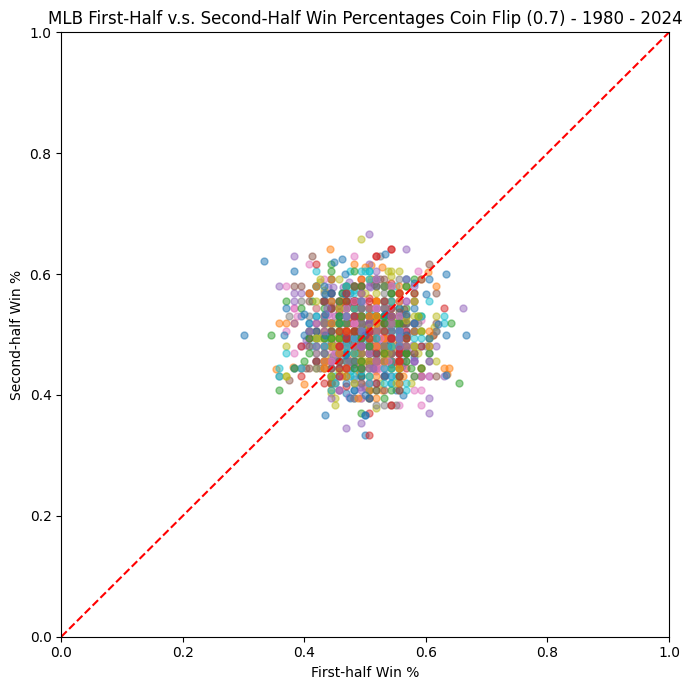

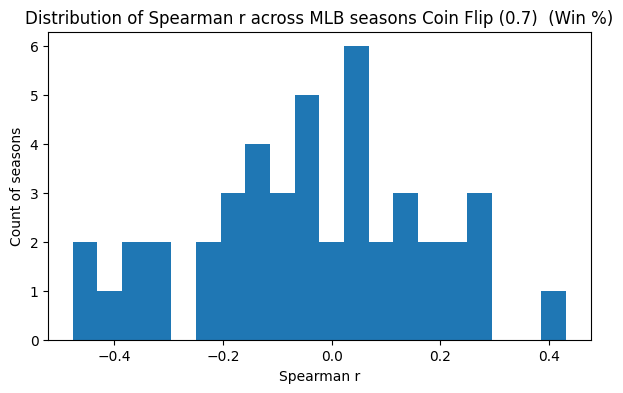


r value meanings:
r closer to 1: first half ranks are very predictive of second half ranks
r closer to 0: first half ranks are NOT very predictive of second half ranks
r negative: reverse tendency. high first half ranks predict low second half ranks, and vice versa


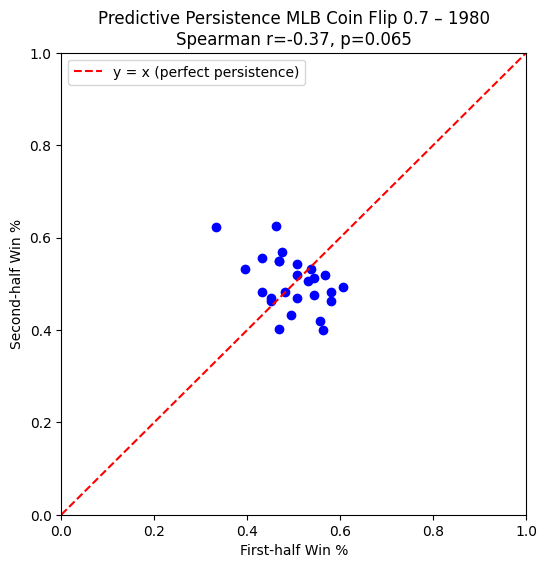

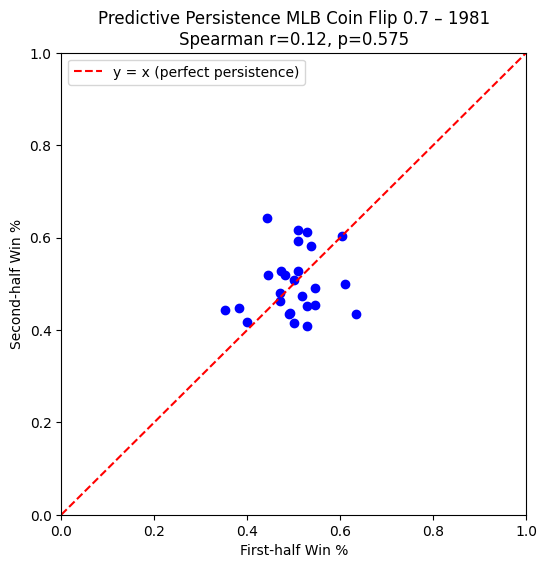

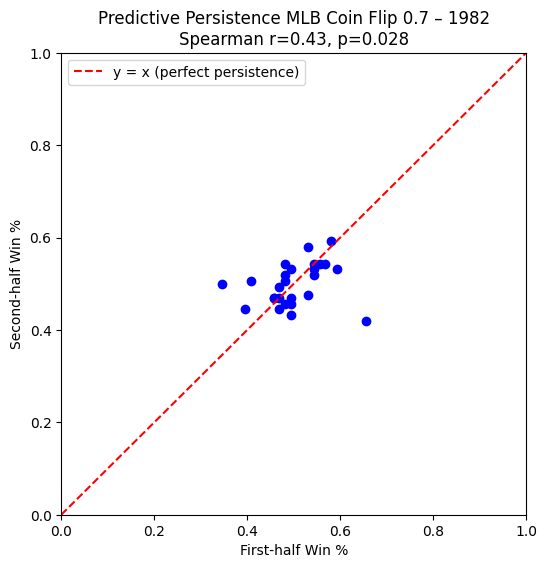

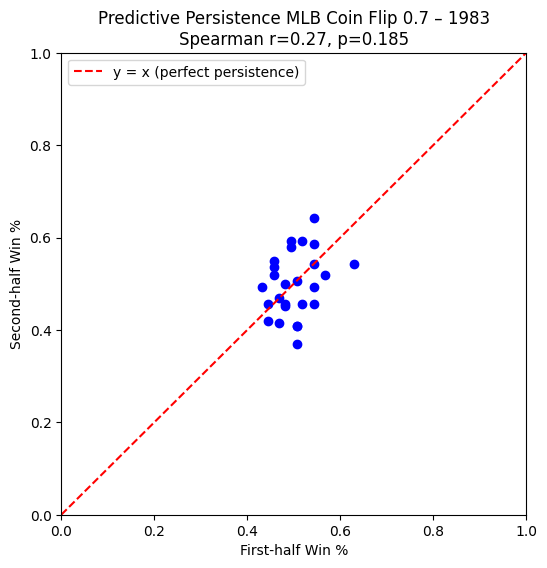

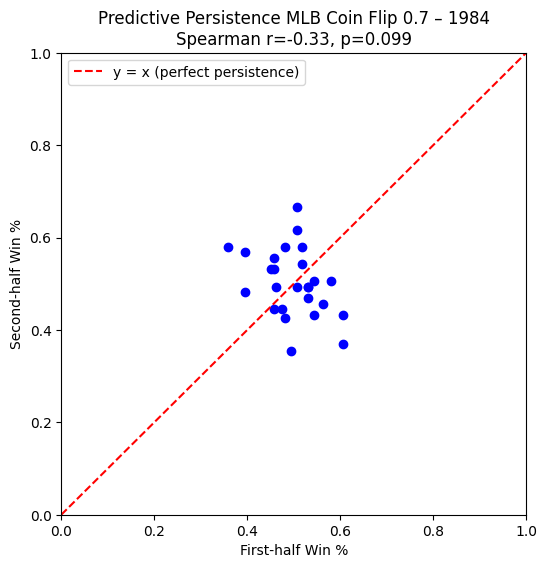

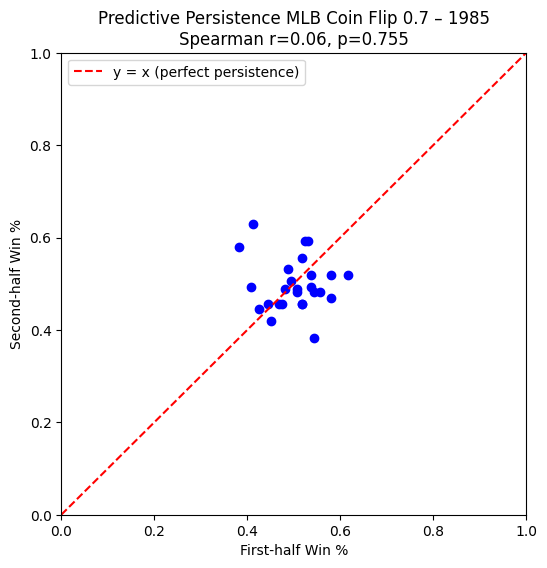

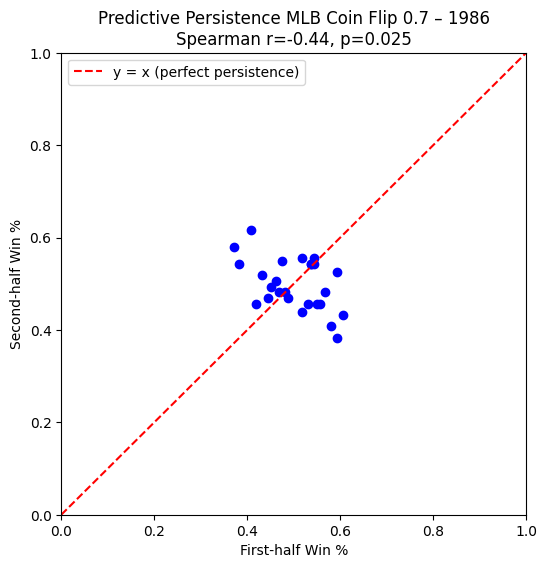

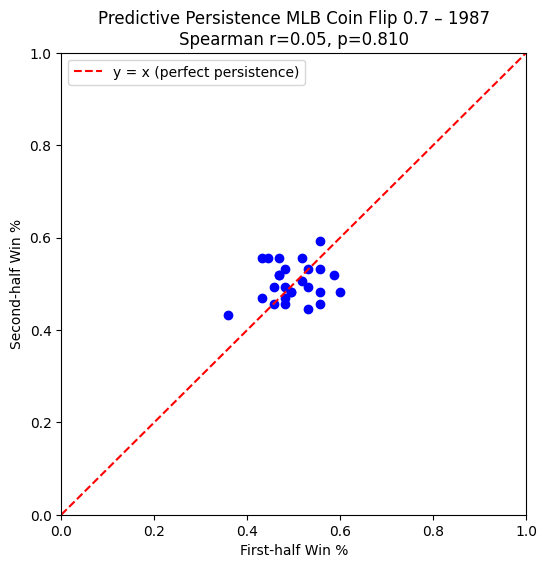

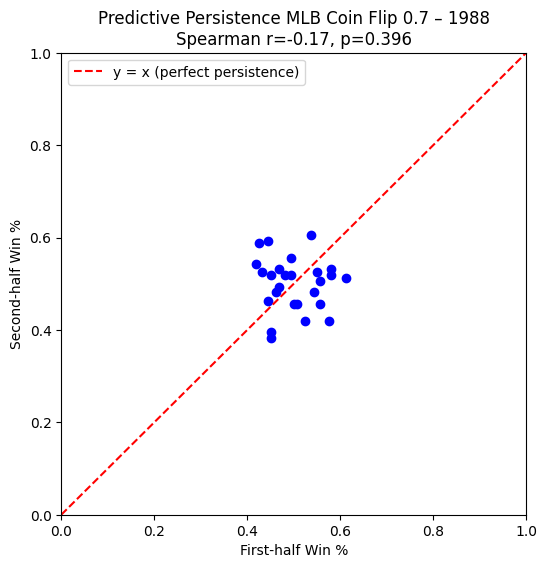

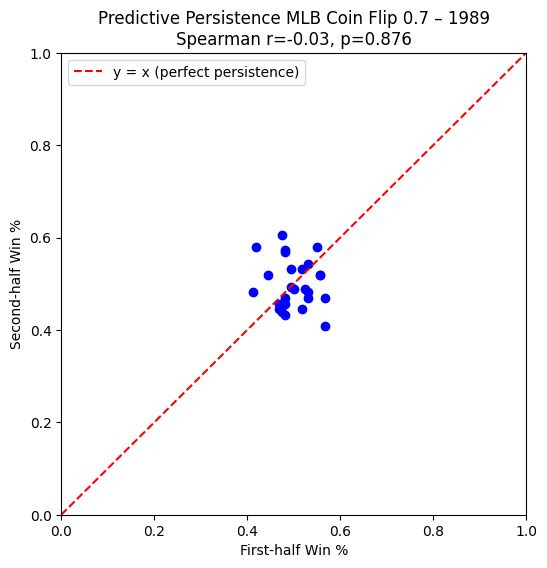

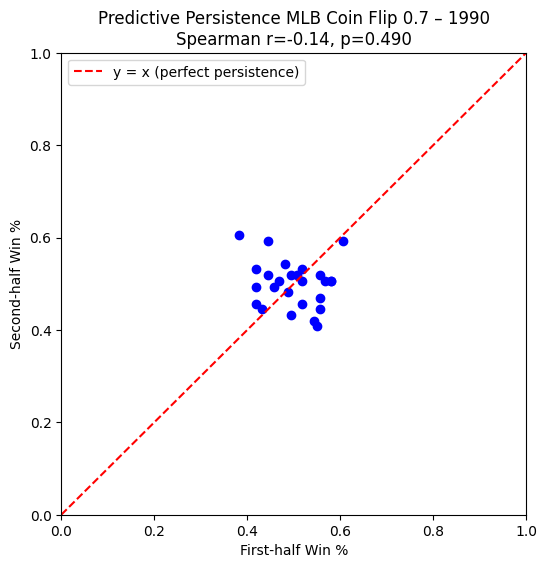

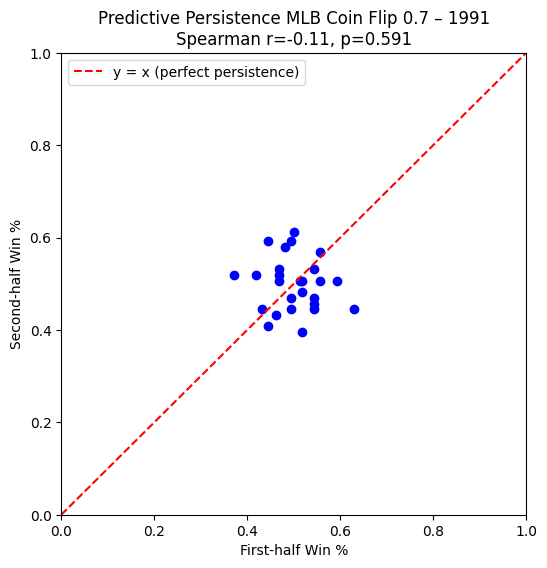

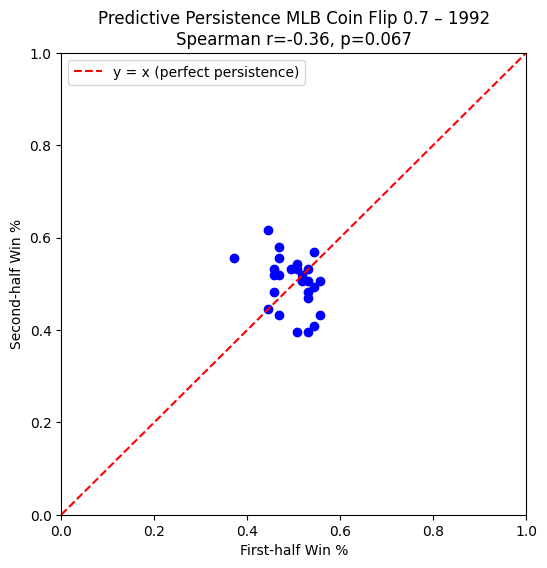

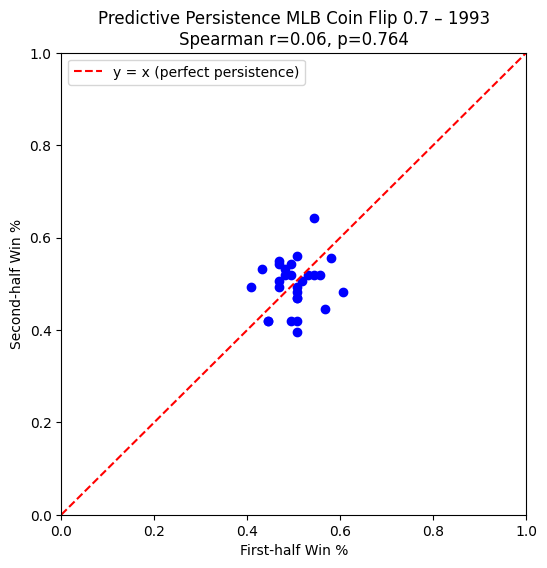

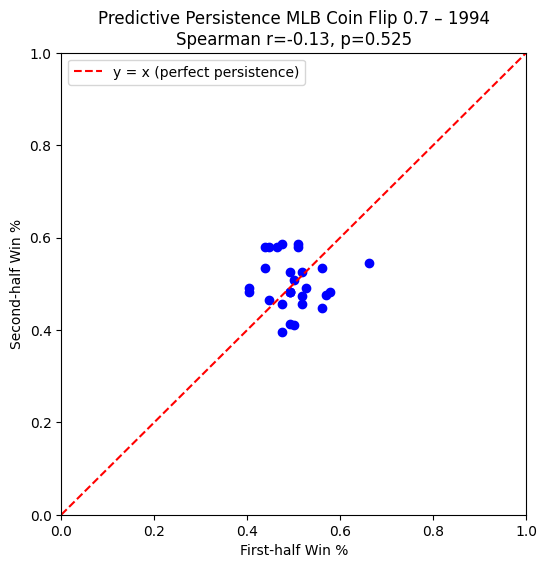

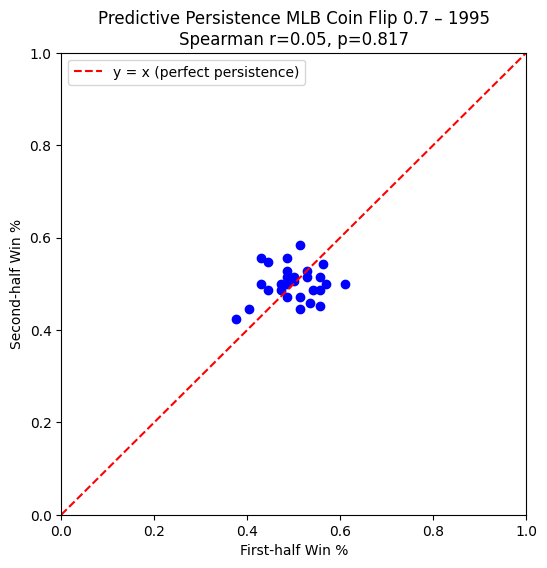

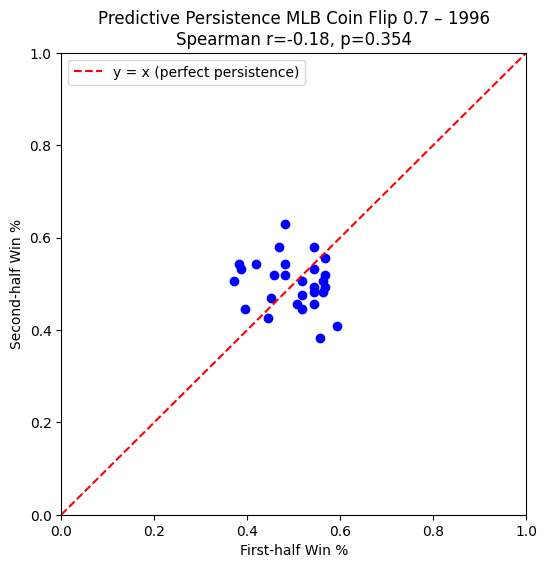

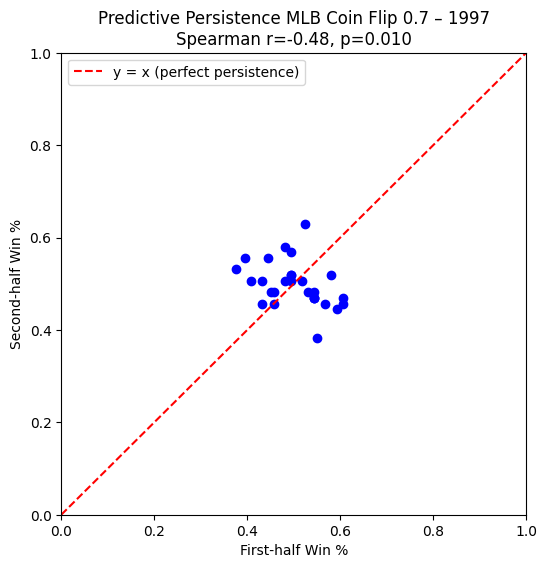

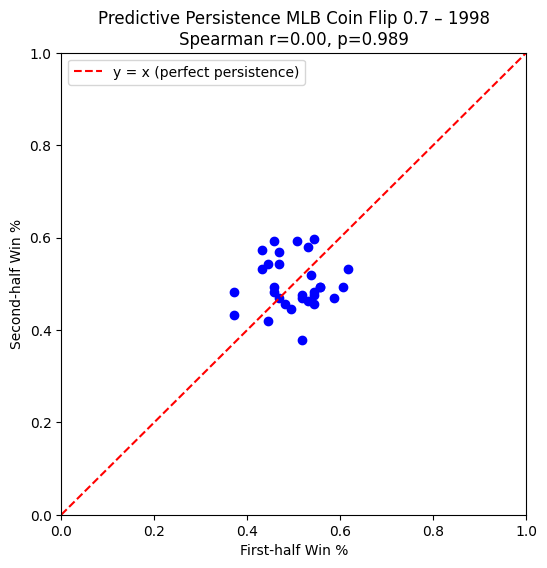

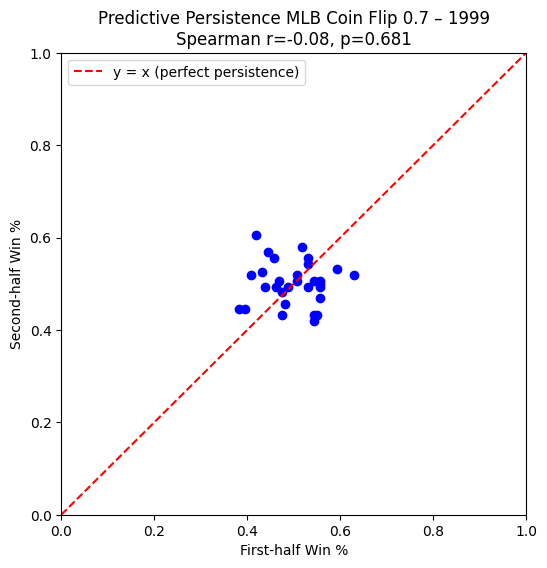

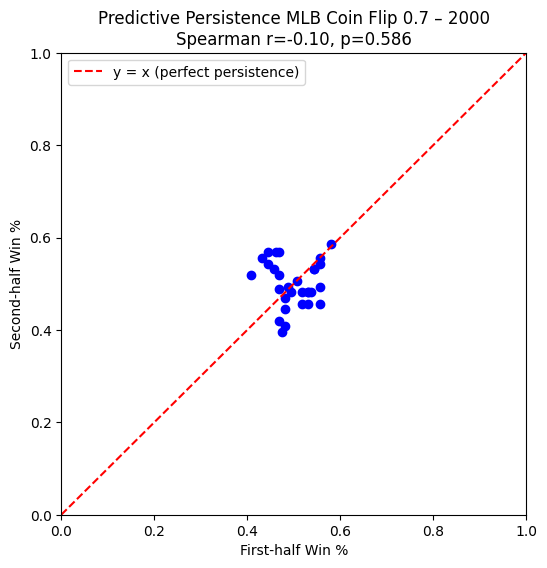

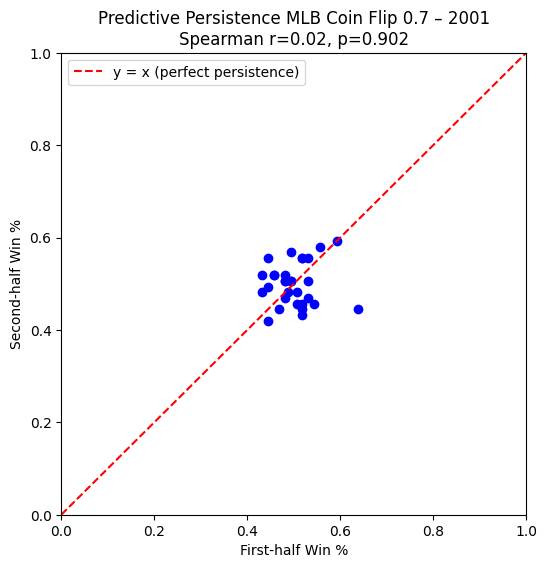

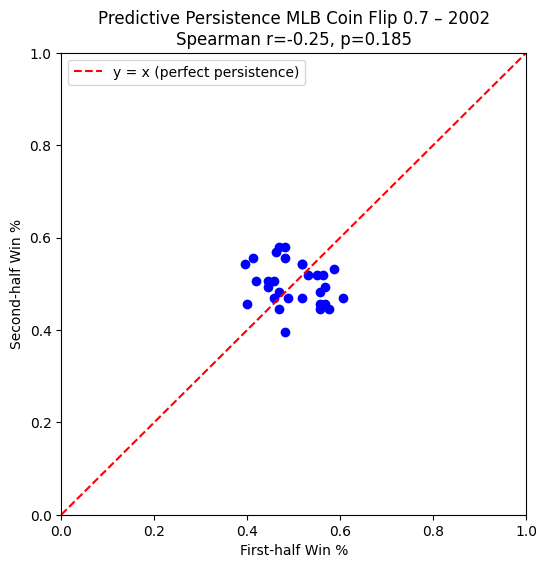

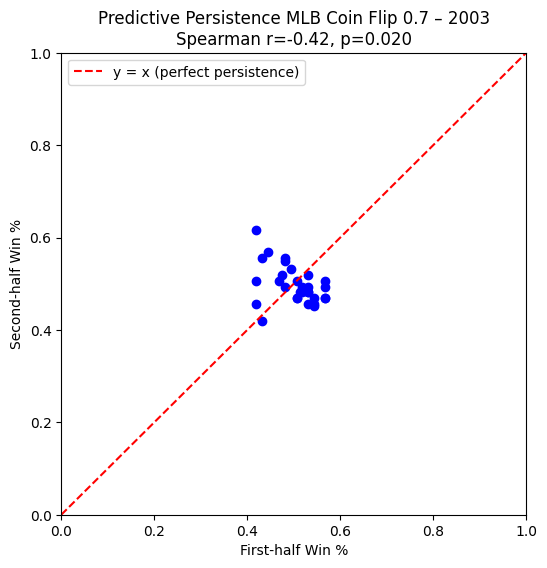

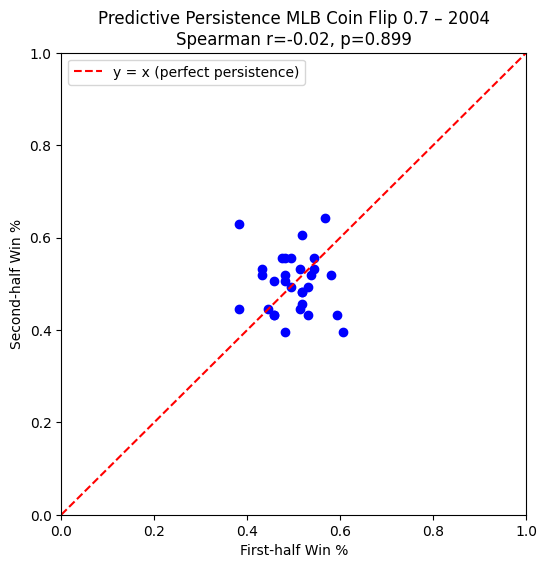

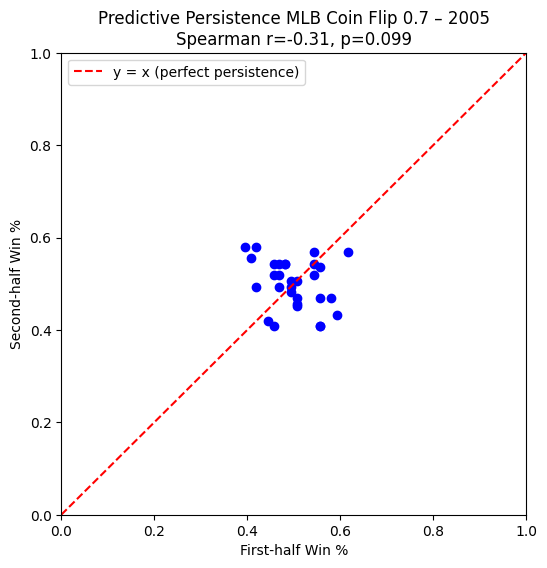

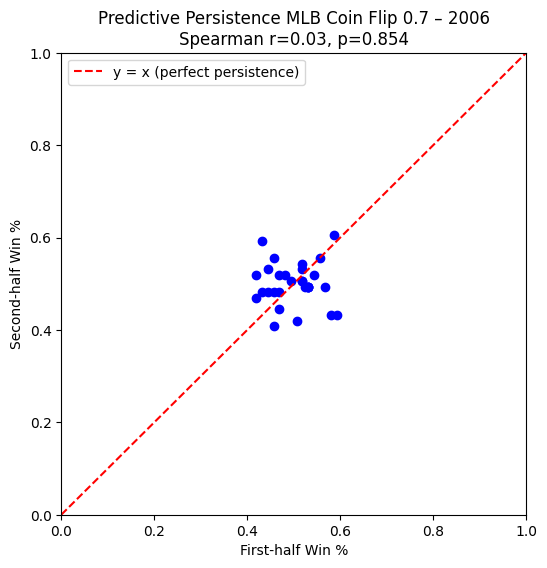

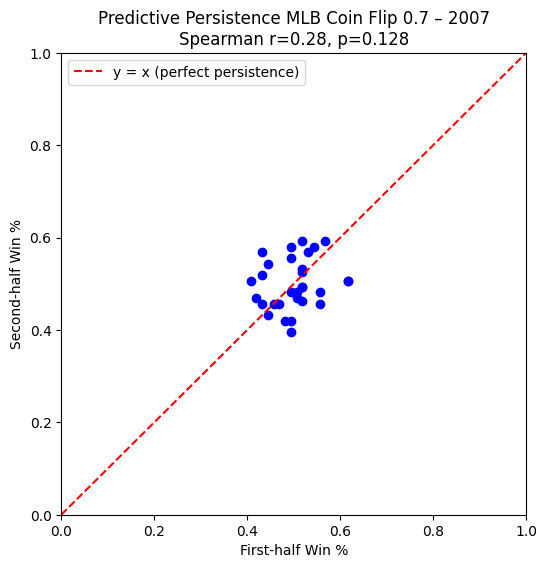

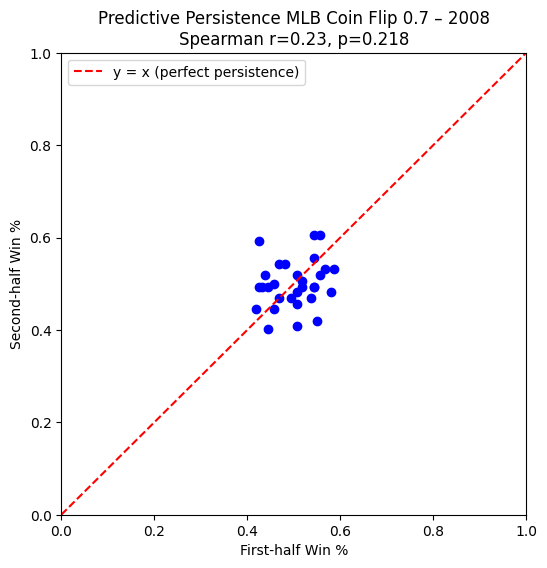

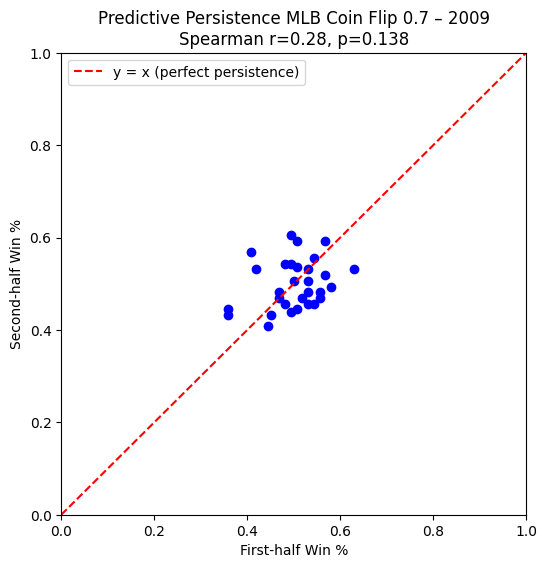

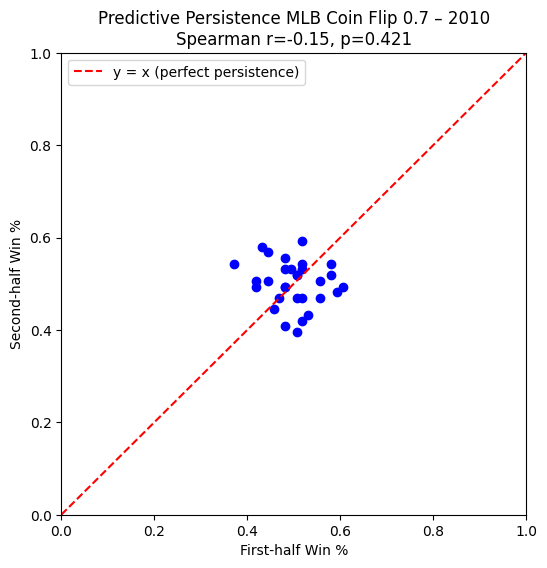

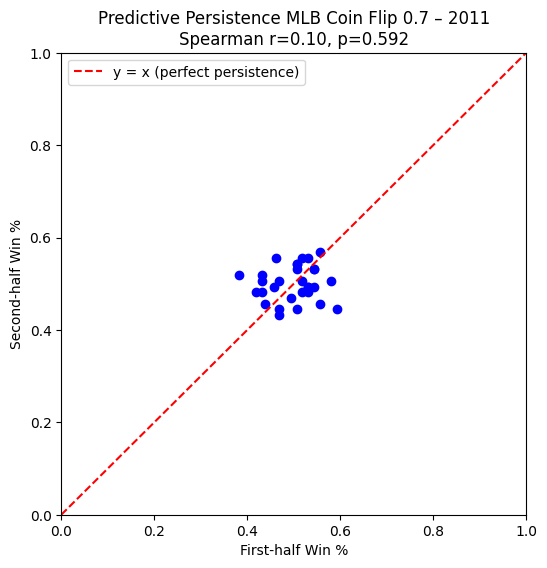

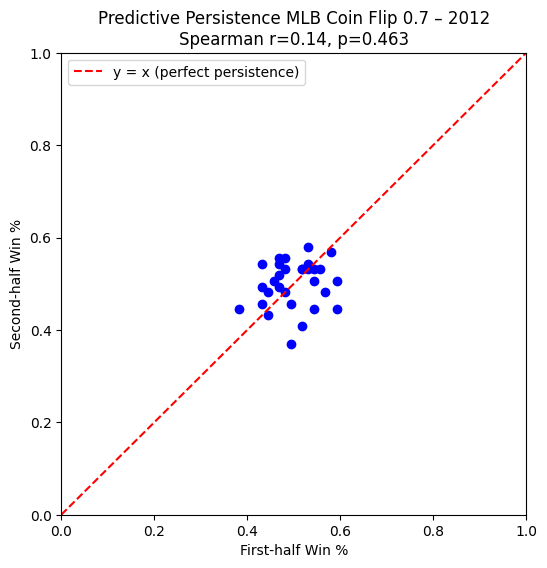

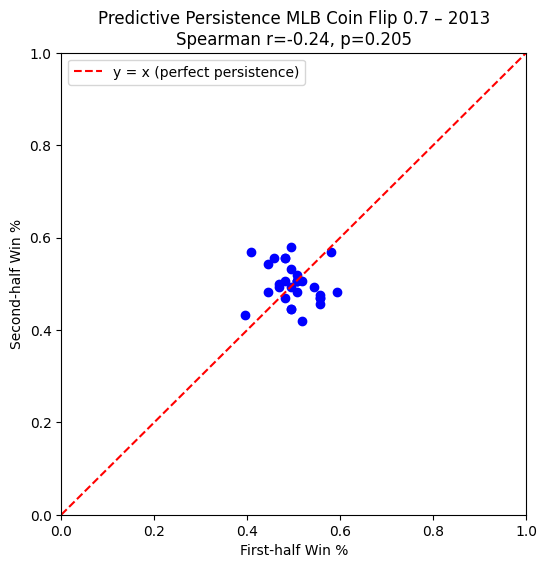

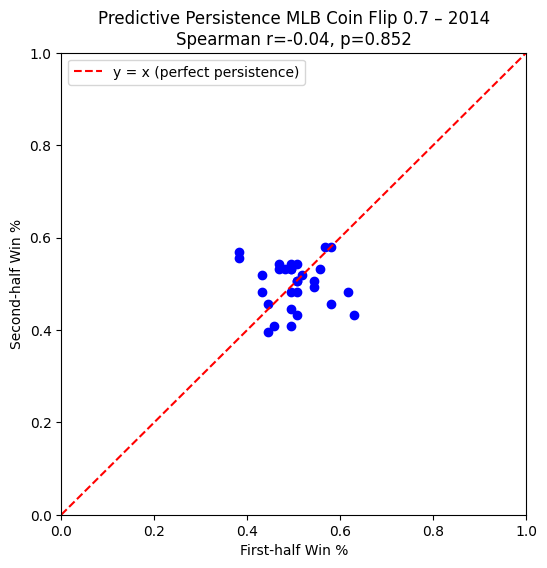

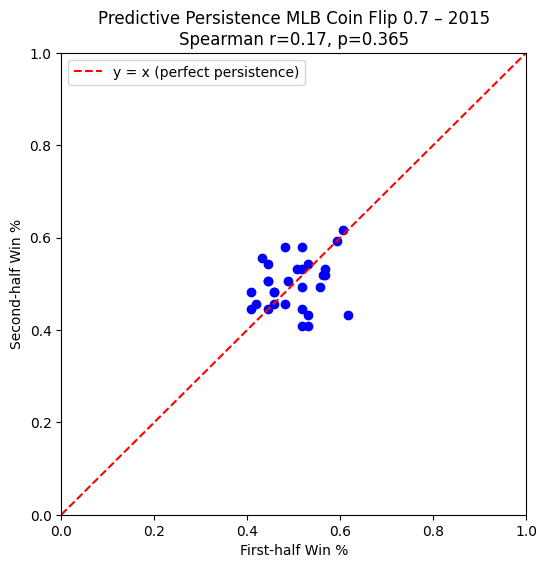

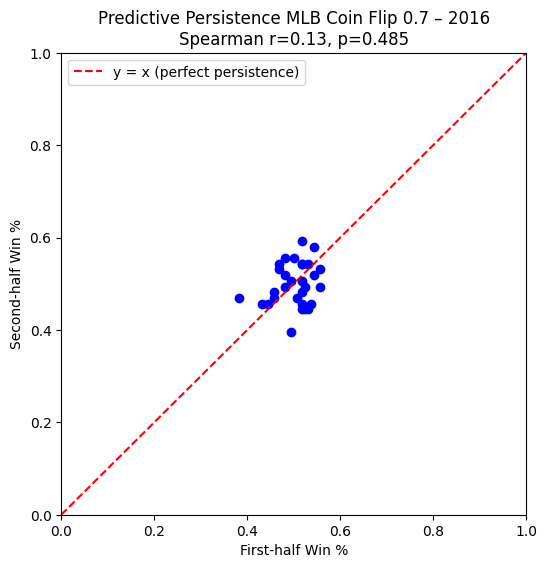

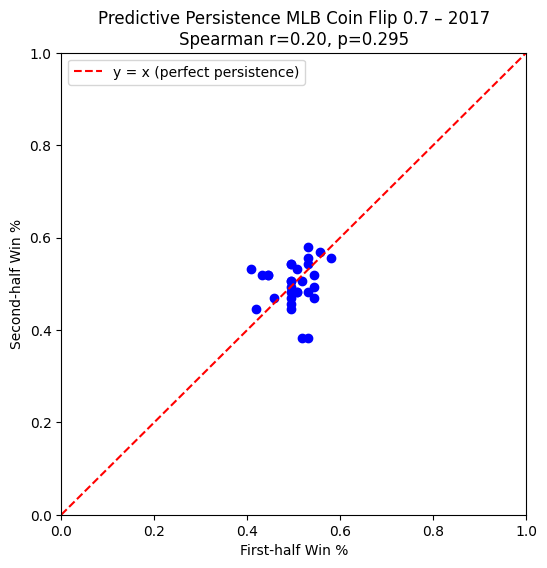

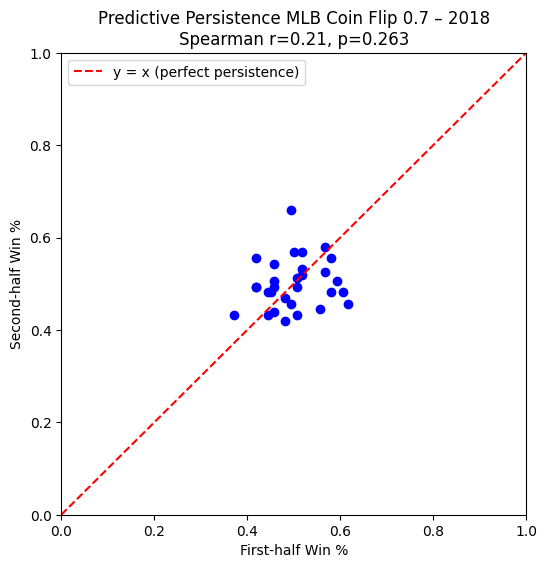

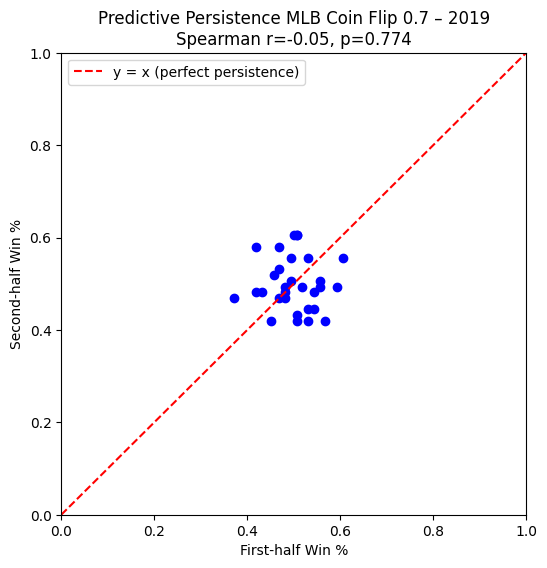

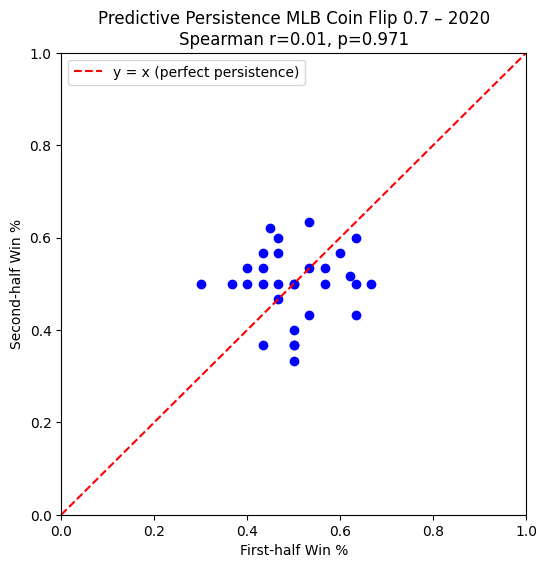

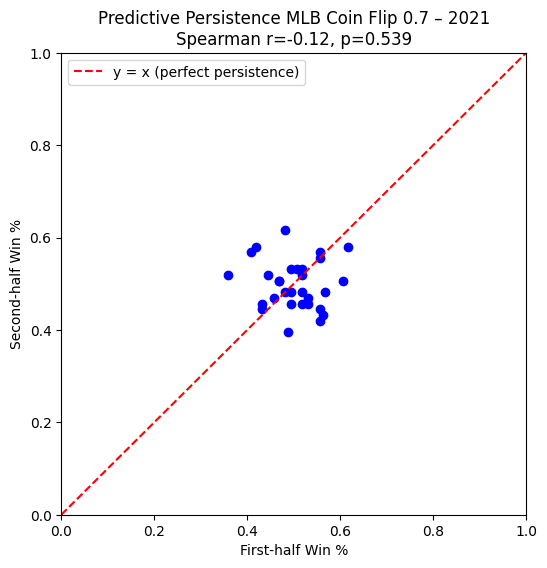

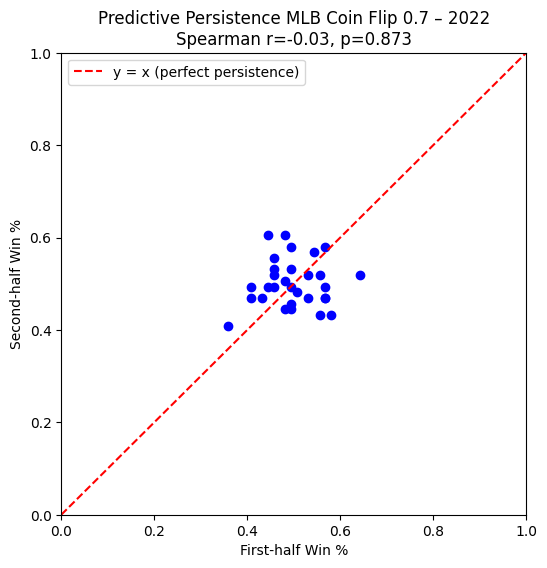

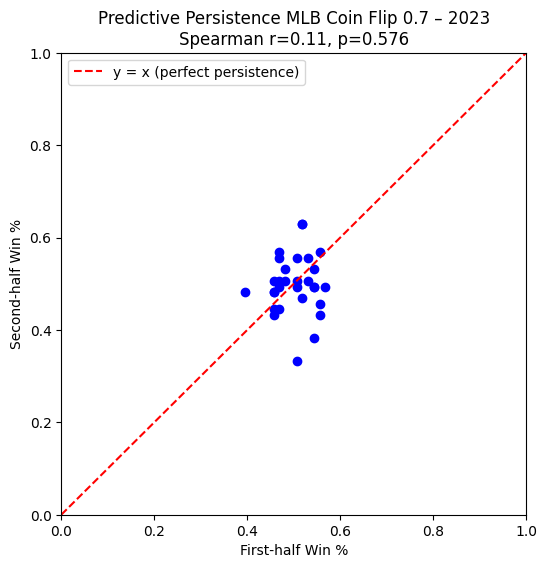

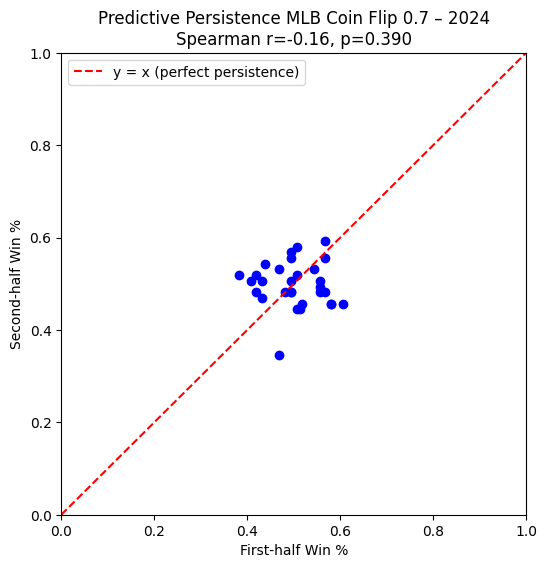

In [24]:
# ============================================================
# Predictive Persistence Analysis (MLB dataset)
# ============================================================

# 0) Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ------------------------------------------------------------
# 1) Load the dataset: MLB
# ------------------------------------------------------------

prob = 0.7  # set 0.5, 0.7, 0.8, etc.
DATA_PATH = f'us_combined_data_coin_flip_{prob:.1f}.csv'

df = pd.read_csv(DATA_PATH)
df = df[df['league'] == 'MLB']
df['date'] = pd.to_datetime(df['date'])

# ------------------------------------------------------------
# 2) Convert into "team-game" format
# We build a table where each original game row
# is viewed from one of the team's point of view.
# Then we can look at, for each team, a section in the table which
# represents their wins and losses throughout the season
# ------------------------------------------------------------

## Team1 Perspective ##
t1 = pd.DataFrame({
    'season': df['season'],
    'date': df['date'],
    'team': df['team1'],
    'opponent': df['team2'],
    'points_for': df['score1'],
    'points_against': df['score2'],
})
# add team's point differential for each game
t1['margin'] = t1['points_for'] - t1['points_against']
# add team's win flag for each game. 1 = win, 0 = loss
# (MLB): ties are possible; encode tie as 0.5 so averages reflect ties
t1['win'] = np.where(t1['margin'] > 0, 1,
                     np.where(t1['margin'] < 0, 0, 0.5))

## Team2 Perspective ##
t2 = pd.DataFrame({
    'season': df['season'],
    'date': df['date'],
    'team': df['team2'],
    'opponent': df['team1'],
    'points_for': df['score2'],
    'points_against': df['score1'],
})
# add team's point differential for each game
t2['margin'] = t2['points_for'] - t2['points_against']
# add team's win flag for each game 1 = win, 0 = loss
# (MLB): ties are possible; encode tie as 0.5 so averages reflect ties
t2['win'] = np.where(t2['margin'] > 0, 1,
                     np.where(t2['margin'] < 0, 0, 0.5))

# Combine both perspectives
# Make a single table with one row per team per game
# (each real game appears twice: once for each team’s perspective).

# stacks rows, and then reindexes the rows to go from row 0 to row N-1
team_games = pd.concat([t1, t2], ignore_index=True)
# reorders rows so they are grouped by season, then by team, then by date
# reindexes the rows to go from row 0 to row N-1, delete old row lab\
team_games = team_games.sort_values(['season','team','date']).reset_index(drop=True)

# ------------------------------------------------------------
# 3) Helper functions
# ------------------------------------------------------------

# define function which takes in the team games, and returns, for
# each season and team, the team's first-half and second-half win percentages
def compute_first_second_halves(team_games):
    rows = [] # initializes an empty list
    # for loop groups team_games by season and team, where
    # (season, team) is the current group key, and
    # grp is a DataFrame containing only that team's rows in the season
    for (season, team), grp in team_games.groupby(['season','team']):
        grp = grp.sort_values('date') # sorts grp by date
        n = len(grp)
        if n < 2: # if game has < 2 games, can't split into halves, so skip
            continue
        split = n // 2 # gives index at which to split the season into two halves
        first = grp.iloc[:split] # take first split rows as first half
        second = grp.iloc[split:]# take second split rows as second half
        if len(first) == 0 or len(second) == 0: # if n was 1, skip
            continue
        m1, m2 = first['win'].mean(), second['win'].mean() # mean = fraction of wins
        # store summary row for this (seaosn, team)
        rows.append({'season': season, 'team': team,
                     'first': m1, 'second': m2,
                     'n_games': n})
    # return the collected list of dictionaries into a DataFrame with cols
    # season, team, first, second, n_games
    return pd.DataFrame(rows)

# define function which plots first-half and second-half win percentage
# for all teams in one season
def plot_season_scatter(grp, season):
    # compute Spearman rank correlation and p_value between first half and second half win percentage
    r_s, p_s = stats.spearmanr(grp['first'], grp['second'])
    plt.figure(figsize=(6,6)) # creates square figure
    plt.scatter(grp['first'], grp['second'], color='blue') # plots one point per team
    # draw y = x line
    xs = np.linspace(0, 1, 100)
    plt.plot(xs, xs, linestyle='--', color='red', label='y = x (perfect persistence)')
    # fix x and y axis to [0,1], label axes, title graph
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('First-half Win %')
    plt.ylabel('Second-half Win %')
    plt.title(f'Predictive Persistence MLB Coin Flip {prob} – {season}\nSpearman r={r_s:.2f}, p={p_s:.3f}')
    plt.legend() # shows label on y = x line
    plt.show()

# define function which takes output of compute_first_second_halves (one row per team-season
# with 'first' and 'second' win percentages) and computes a per-season Spearman correlation.
def season_correlations(first_second_df):
    out = []  # collect one dict per season with Spearman stats
    for season, grp in first_second_df.groupby('season'):
        # Need variation and enough teams; otherwise correlation is undefined or meaningless
        if grp['first'].nunique() <= 1 or grp['second'].nunique() <= 1 or len(grp) < 3:
            continue
          # rank each array
        r_s, p_s = stats.spearmanr(grp['first'], grp['second'])
        out.append({
            'season': season,
            'n_teams': len(grp),
            'spearman_r': r_s,
            'spearman_p': p_s
        })
      # store stats for the season: number of teams,
      # spearman r-val (correlation between first half and second half win %
      # across teams in that season), p-val
    return pd.DataFrame(out).sort_values('season')


# ------------------------------------------------------------
# 4) Run predictive persistence analysis
# ------------------------------------------------------------

# get per team per season summaries
fs_win = compute_first_second_halves(team_games)
# give the summaries to the correlation helper
corr_win = season_correlations(fs_win)
# NOTE (MLB): 'win' averages above include ties as 0.5, so they reflect ties in “win%”

# ------------------------------------------------------------
# 5) One combined plot with ALL seasons overlaid
#    Title format: "Predictive Persistence NBA - [lowest season - highest season]"
# ------------------------------------------------------------

if not fs_win.empty:
    min_season = int(fs_win['season'].min())
    max_season = int(fs_win['season'].max())

    plt.figure(figsize=(7,7))
    # Overlay each season's points; label only if few seasons to avoid clutter
    for season, grp in fs_win.groupby('season'):
        plt.scatter(grp['first'], grp['second'], alpha=0.5, s=25, label=str(season))

    # create plot
    xs = np.linspace(0, 1, 100)
    plt.plot(xs, xs, linestyle='--', color='red', label='y = x (perfect persistence)')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('First-half Win %')
    plt.ylabel('Second-half Win %')
    plt.title(f'MLB First-Half v.s. Second-Half Win Percentages Coin Flip ({prob}) - {min_season} - {max_season}')

    #  show labels only if the number of seasons is small
    if fs_win['season'].nunique() <= 15:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 6) Histogram of Spearman correlations across seasons
# ------------------------------------------------------------

if not corr_win.empty:
    plt.figure(figsize=(7,4))
    plt.hist(corr_win['spearman_r'].dropna(), bins=20)
    plt.title(f'Distribution of Spearman r across MLB seasons Coin Flip ({prob})  (Win %)')
    plt.xlabel('Spearman r')
    plt.ylabel('Count of seasons')
    plt.show()
    print("\nr value meanings:")
    print("r closer to 1: first half ranks are very predictive of second half ranks")
    print("r closer to 0: first half ranks are NOT very predictive of second half ranks")
    print("r negative: reverse tendency. high first half ranks predict low second half ranks, and vice versa")

# ------------------------------------------------------------
# 7) Plot scatterplots for ALL seasons
# ------------------------------------------------------------

for season, grp in fs_win.groupby('season'):
    if len(grp) >= 3: # don't print scatter plot if less than 3 teams
        plot_season_scatter(grp, season)